# 🧮 Odometer Pilot: LLM Counting Failure Study

**Research question:** Does Llama-3.2-1B-Instruct possess a stable positional counter
that operates independently of token semantics?

| Phase | Stimuli | Expected | Tests |
|-------|---------|----------|-------|
| 1 — Baseline | `apple ×10` | 10 | Identical-token counting |
| 2 — Anomaly | `apple ×9 + banana at pos 5` | 9 | Semantic interference |
| 3 — Control | `10 unique words` | 10 | Content-independent tracking |

**Hypothesis:** If Phase 2 accuracy drops relative to Phase 1, the model's counter is
disrupted by token identity rather than position — consistent with attention-pattern
failure rather than a true odometer.


## 0 · Install dependencies

In [1]:
# Run once per environment
%pip install transformers scikit-learn torch accelerate matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from huggingface_hub import login
login()

## 1 · Imports & configuration

In [36]:
import re
import json
import random
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME     = "meta-llama/Llama-3.2-3B-Instruct"
N_RUNS         = 10          # repetitions per phase (use 1 for greedy/deterministic)
SEEDS          = list(range(N_RUNS))
TEMPERATURE    = 0.0         # near-greedy; set to 0 + do_sample=False for pure greedy
MAX_NEW_TOKENS = 16
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
CRITICAL_LAYERS = [22, 23, 24, 25, 26, 27, 28]

print(f"Device: {DEVICE}")
print(f"N_RUNS: {N_RUNS}, TEMPERATURE: {TEMPERATURE}")

Device: cuda
N_RUNS: 10, TEMPERATURE: 0.0


## 2 · Define prompts

In [5]:
PROMPTS = {
    "phase1_baseline": {
        "text": (
            'Count the number of times "apple" appears in this list: '
            "apple apple apple apple apple apple apple apple apple apple. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 10,
        "description": "10 identical tokens (apple ×10)",
    },
    "phase2_anomaly": {
        "text": (
            'Count the number of times "apple" appears in this list: '
            "apple apple apple apple banana apple apple apple apple apple. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 9,
        "description": "9 apple + 1 banana at position 5",
    },
    "phase3_control": {
        "text": (
            "Count the number of words in this list: "
            "dog cat car red blue green house tree book pen. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 10,
        "description": "10 unique tokens (distinct words)",
    },
}

# Preview
for k, v in PROMPTS.items():
    print(f"[{k}]\n  Expected : {v['expected']}\n  Prompt   : {v['text'][:80]}...\n")


[phase1_baseline]
  Expected : 10
  Prompt   : Count the number of times "apple" appears in this list: apple apple apple apple ...

[phase2_anomaly]
  Expected : 9
  Prompt   : Count the number of times "apple" appears in this list: apple apple apple apple ...

[phase3_control]
  Expected : 10
  Prompt   : Count the number of words in this list: dog cat car red blue green house tree bo...



## 3 · Load model & tokenizer

In [52]:
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto",
)

print("Model loaded successfully.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading meta-llama/Llama-3.2-3B-Instruct...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Model loaded successfully.
Parameters: 3.21B


## 4 · Extraction helper

In [7]:
def extract_count(raw_output: str) -> Optional[int]:
    """
    With return_full_text=False the pipeline returns ONLY newly generated tokens,
    so generated_text is just the model answer (e.g. "10" or "The answer is 9.").
    Grab the first standalone integer.
    """
    match = re.search(r'\b(\d+)\b', raw_output.strip())
    return int(match.group(1)) if match else None


# Sanity check
assert extract_count("10") == 10
assert extract_count("The answer is 9.") == 9
assert extract_count("\n\n10\n") == 10
assert extract_count("no number here") is None
print("Extraction helper OK.")


Extraction helper OK.


## 5 · Run a single phase (one seed)

In [8]:
def run_single(phase_key: str, seed: int) -> dict:
    entry  = PROMPTS[phase_key]
    prompt = entry["text"]

    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # KEY FIX 1: pass messages list, not raw string
    # Llama-3.2-1B-Instruct requires the chat template to be applied;
    # a raw string bypasses instruction-following and the model just continues text.
    #
    # KEY FIX 2: return_full_text=False
    # Returns ONLY newly generated tokens, not prompt + answer.
    # Without this, generated_text = chat_template_prefix + prompt + answer,
    # and the regex fires on a number inside the prompt/template, not the answer.
    raw = pipe(
    [{"role": "user", "content": entry["text"]}],
    max_new_tokens=MAX_NEW_TOKENS,
    do_sample=False,
    temperature=None,
    pad_token_id=pipe.tokenizer.eos_token_id,
    return_full_text=False,
    max_length=None,   # explicitly unset the generation_config default
    )[0]["generated_text"].strip()

    predicted = extract_count(raw)
    correct   = (predicted == entry["expected"]) if predicted is not None else False

    return {
        "seed"      : seed,
        "raw"       : raw,         # full model answer (short now)
        "predicted" : predicted,
        "expected"  : entry["expected"],
        "correct"   : correct,
    }


## 6 · Run full experiment across all phases

In [9]:
all_results = {}

for phase_key, entry in PROMPTS.items():
    print(f"\n{chr(9472)*55}")
    print(f"  {phase_key.upper()}  |  {entry['description']}")
    print(f"{chr(9472)*55}")

    phase_results = []
    for seed in SEEDS:
        r      = run_single(phase_key, seed)
        status = "✓" if r["correct"] else "✗"
        # Print raw output so you can spot pathological responses immediately
        print(f"  seed={seed:02d}  predicted={str(r['predicted']):>4}  expected={r['expected']}  {status}  raw={repr(r['raw'][:40])}")
        phase_results.append(r)

    all_results[phase_key] = phase_results

The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



───────────────────────────────────────────────────────
  PHASE1_BASELINE  |  10 identical tokens (apple ×10)
───────────────────────────────────────────────────────


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=00  predicted=  14  expected=10  ✗  raw='14'
  seed=01  predicted=  14  expected=10  ✗  raw='14'
  seed=02  predicted=  14  expected=10  ✗  raw='14'
  seed=03  predicted=  14  expected=10  ✗  raw='14'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  seed=00  predicted=  11  expected=10  ✗  raw='11'
  seed=01  predicted=  11  expected=10  ✗  raw='11'
  seed=02  predicted=  11  expected=10  ✗  raw='11'
  seed=03  predicted=  11  expected=10  ✗  raw='11'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=04  predicted=  11  expected=10  ✗  raw='11'
  seed=05  predicted=  11  expected=10  ✗  raw='11'
  seed=06  predicted=  11  expected=10  ✗  raw='11'
  seed=07  predicted=  11  expected=10  ✗  raw='11'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=08  predicted=  11  expected=10  ✗  raw='11'
  seed=09  predicted=  11  expected=10  ✗  raw='11'


## 7 · Summary statistics

In [10]:
@dataclass
class PhaseSummary:
    phase       : str
    description : str
    expected    : int
    n_runs      : int
    predictions : list = field(default_factory=list)
    n_correct   : int  = 0

    def add(self, r):
        self.predictions.append(r["predicted"])
        if r["correct"]: self.n_correct += 1

    def accuracy(self) -> float:
        return self.n_correct / self.n_runs

    def dist(self) -> dict:
        return dict(Counter(str(p) for p in self.predictions))


summaries = {}
for phase_key, results in all_results.items():
    s = PhaseSummary(
        phase       = phase_key,
        description = PROMPTS[phase_key]["description"],
        expected    = PROMPTS[phase_key]["expected"],
        n_runs      = N_RUNS,
    )
    for r in results: s.add(r)
    summaries[phase_key] = s

print(f"{'Phase':<22} {'Accuracy':>10}  {'Distribution of predictions'}")
print("─" * 65)
for k, s in summaries.items():
    print(f"{k:<22} {s.accuracy():>9.0%}  {s.dist()}")


Phase                    Accuracy  Distribution of predictions
─────────────────────────────────────────────────────────────────
phase1_baseline               0%  {'14': 10}
phase2_anomaly                0%  {'8': 10}
phase3_control                0%  {'11': 10}


## 8 · Visualise accuracy per phase

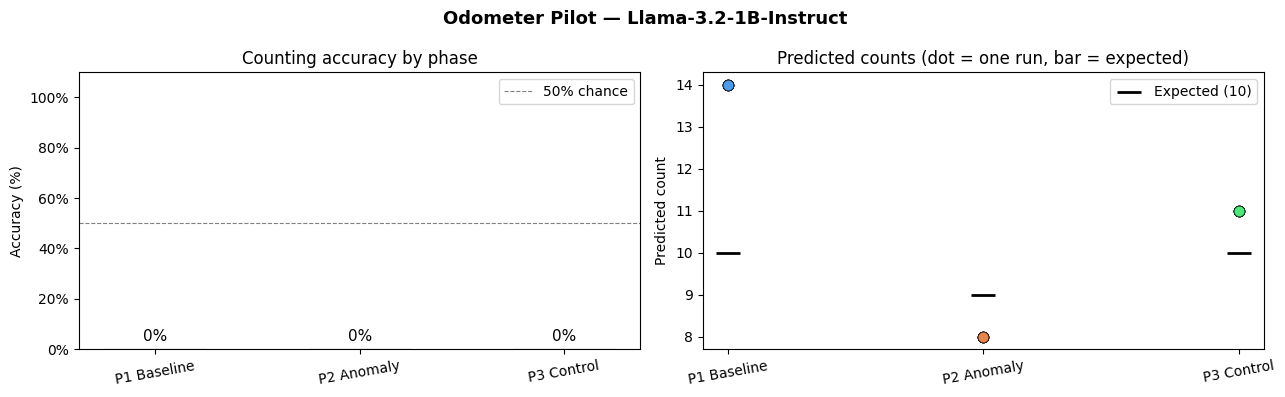

Figure saved to odometer_results.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

labels   = list(summaries.keys())
accs     = [summaries[k].accuracy() * 100 for k in labels]
colors   = ["#4c9be8", "#e8844c", "#4ce87a"]
expected = [summaries[k].expected for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Odometer Pilot — Llama-3.2-1B-Instruct", fontsize=13, fontweight="bold")

# Left: accuracy bars
ax = axes[0]
bars = ax.bar(labels, accs, color=colors, edgecolor="black", linewidth=0.8, width=0.5)
ax.axhline(50, linestyle="--", color="grey", linewidth=0.8, label="50% chance")
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Counting accuracy by phase")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(["P1 Baseline", "P2 Anomaly", "P3 Control"], rotation=10)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{acc:.0f}%", ha="center", va="bottom", fontsize=11)
ax.legend()

# Right: prediction distributions as dot plots
ax2 = axes[1]
for i, (k, col) in enumerate(zip(labels, colors)):
    preds = summaries[k].predictions
    for p in preds:
        ax2.scatter(i, p if p is not None else -1, color=col,
                    alpha=0.6, s=60, edgecolors="black", linewidths=0.5)
    ax2.scatter(i, expected[i], marker="_", s=300, color="black",
                linewidths=2, zorder=5, label=f"Expected ({expected[i]})" if i==0 else "")

ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(["P1 Baseline", "P2 Anomaly", "P3 Control"], rotation=10)
ax2.set_ylabel("Predicted count")
ax2.set_title("Predicted counts (dot = one run, bar = expected)")
ax2.legend()

plt.tight_layout()
plt.savefig("odometer_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to odometer_results.png")


In [12]:
# ── Behavioral n-sweep ────────────────────────────────────────────────────
# Sweep n from 5 to 20 for both P1 (repeated) and P3 (unique)
# to characterize the attractor across counts, not just at n=10

unique_vocab = ["dog", "cat", "car", "red", "blue", "green",
                "house", "tree", "book", "pen", "fish", "cup",
                "hat", "sun", "moon", "sky", "fire", "rain",
                "snow", "wind"]

NS = [5, 6, 7, 8, 9, 10, 11, 12, 15, 20]

print("=" * 65)
print("BEHAVIORAL N-SWEEP — 1B")
print("=" * 65)
print(f"  {'n':>4}  {'P1 output':>10}  {'P1 correct':>11}  {'P3 output':>10}  {'P3 correct':>11}")
print("  " + "-" * 55)

sweep_behavioral = {}

for n in NS:
    prompt_p1 = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    prompt_p3 = (
        "Count the number of words in this list: "
        + " ".join(unique_vocab[:n])
        + ". Respond only with the integer, nothing else."
    )

    raw_p1 = pipe(
        [{"role": "user", "content": prompt_p1}],
        max_new_tokens=8, temperature=0.0, do_sample=False,
        pad_token_id=tokenizer.eos_token_id, return_full_text=False,
    )[0]["generated_text"].strip()

    raw_p3 = pipe(
        [{"role": "user", "content": prompt_p3}],
        max_new_tokens=8, temperature=0.0, do_sample=False,
        pad_token_id=tokenizer.eos_token_id, return_full_text=False,
    )[0]["generated_text"].strip()

    pred_p1 = extract_count(raw_p1)
    pred_p3 = extract_count(raw_p3)
    corr_p1 = "✓" if pred_p1 == n else "✗"
    corr_p3 = "✓" if pred_p3 == n else "✗"

    print(f"  {n:>4}  {str(pred_p1):>10}  {corr_p1:>11}  {str(pred_p3):>10}  {corr_p3:>11}")
    sweep_behavioral[n] = {
        "n"        : n,
        "p1_output": pred_p1, "p1_correct": pred_p1 == n,
        "p3_output": pred_p3, "p3_correct": pred_p3 == n,
    }

# Attractor summary
print("\nP1 attractor pattern:")
for n, r in sweep_behavioral.items():
    marker = "= n (correct)" if r["p1_correct"] else f"≠ n (wrong, got {r['p1_output']})"
    print(f"  n={n:>2}  output={r['p1_output']}  {marker}")

with open("behavioral_n_sweep.json", "w") as f:
    json.dump({str(k): v for k, v in sweep_behavioral.items()}, f, indent=2)
print("\nSaved: behavioral_n_sweep.json")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Pleas

BEHAVIORAL N-SWEEP — 1B
     n   P1 output   P1 correct   P3 output   P3 correct
  -------------------------------------------------------
     5           5            ✓           5            ✓


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     6           6            ✓           7            ✗
     7           7            ✓           8            ✗


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


     8           8            ✓           9            ✗
     9           8            ✗           9            ✓


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    10          14            ✗          11            ✗
    11          14            ✗          12            ✗


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


    12          14            ✗          12            ✓
    15          14            ✗          17            ✗
    20          14            ✗          17            ✗

P1 attractor pattern:
  n= 5  output=5  = n (correct)
  n= 6  output=6  = n (correct)
  n= 7  output=7  = n (correct)
  n= 8  output=8  = n (correct)
  n= 9  output=8  ≠ n (wrong, got 8)
  n=10  output=14  ≠ n (wrong, got 14)
  n=11  output=14  ≠ n (wrong, got 14)
  n=12  output=14  ≠ n (wrong, got 14)
  n=15  output=14  ≠ n (wrong, got 14)
  n=20  output=14  ≠ n (wrong, got 14)

Saved: behavioral_n_sweep.json


## 9 · Diagnostic interpretation

In [13]:
acc1 = summaries["phase1_baseline"].accuracy()
acc2 = summaries["phase2_anomaly"].accuracy()
acc3 = summaries["phase3_control"].accuracy()

print("DIAGNOSTIC INTERPRETATION")

# Baseline
if acc1 < 0.4:
    print("\n[Phase 1 — BASELINE FAILURE]")
    print("  The model lacks even a basic positional counter for identical tokens.")
elif acc1 >= 0.8:
    print("\n[Phase 1 — BASELINE STRONG]")
    print("  Model counts identical tokens reliably.")
else:
    print("\n[Phase 1 — BASELINE WEAK]")
    print("  Partial success — the counter is noisy even without interference.")

# Anomaly vs baseline
delta_12 = acc1 - acc2
if delta_12 > 0.3:
    print("\n[Phase 2 — SEMANTIC INTERFERENCE CONFIRMED]")
    print(f"  Accuracy dropped {delta_12:.0%} when a single intruder token was inserted.")
    print("  Consistent with attention-pattern disruption rather than a content-free odometer.")
elif delta_12 < 0:
    print("\n[Phase 2 — INTRUDER HELPS? (unexpected)]")
    print("  Accuracy improved with the anomaly. Possible novelty-driven attention effect.")
else:
    print("\n[Phase 2 — ANOMALY HAS LITTLE EFFECT]")
    print("  Intruder token does not significantly disrupt counting.")

# Control vs baseline
delta_13 = acc3 - acc1
if delta_13 > 0.2:
    print("\n[Phase 3 — UNIQUE TOKENS IMPROVE COUNTING]")
    print("  Distinct tokens provide better positional anchoring than repetitions.")
    print("  Suggests the failure in P1/P2 is tied to attention-sink dynamics on repeated tokens.")
elif delta_13 < -0.2:
    print("\n[Phase 3 — REPETITION HELPS COUNTING]")
    print("  Model is actually better at counting repeated tokens — pattern-matching hypothesis.")
else:
    print("\n[Phase 3 — TOKEN IDENTITY IS NOT THE PRIMARY DRIVER]")
    print("  Similar accuracy with unique vs repeated tokens.")

print()
print(f"  P1 Baseline : {acc1:.0%}")
print(f"  P2 Anomaly  : {acc2:.0%}  (Δ vs P1: {acc2-acc1:+.0%})")
print(f"  P3 Control  : {acc3:.0%}  (Δ vs P1: {acc3-acc1:+.0%})")


DIAGNOSTIC INTERPRETATION

[Phase 1 — BASELINE FAILURE]
  The model lacks even a basic positional counter for identical tokens.

[Phase 2 — ANOMALY HAS LITTLE EFFECT]
  Intruder token does not significantly disrupt counting.

[Phase 3 — TOKEN IDENTITY IS NOT THE PRIMARY DRIVER]
  Similar accuracy with unique vs repeated tokens.

  P1 Baseline : 0%
  P2 Anomaly  : 0%  (Δ vs P1: +0%)
  P3 Control  : 0%  (Δ vs P1: +0%)


In [14]:
# The hypothesis it tests: 
# "apple apple..." with leading spaces fuses into BPE units like ["apple", " apple", " apple", ...] 
# — which is fewer than 10 tokens if any consecutive pair gets merged. 
# If token count == 8 comes out, the model saying "8" is actually mechanistically correct (it counted tokens), and the experiment is measuring the wrong thing.
# ── Diagnostic 1: Tokenization of payloads ────────────────────────────────
print("PAYLOAD TOKENIZATION DIAGNOSTIC")

for phase_key, entry in PROMPTS.items():
    # Extract just the word-list portion of the prompt
    payload = entry["text"].split(": ")[1].split(". Respond")[0]
    toks = tokenizer.encode(payload, add_special_tokens=False)
    decoded = [tokenizer.decode([t]) for t in toks]

    print(f"\n[{phase_key}]")
    print(f"  Payload        : {payload}")
    print(f"  Word count     : {len(payload.split())}")
    print(f"  Token count    : {len(toks)}")
    print(f"  Expected answer: {entry['expected']}")
    print(f"  Tokens         : {decoded}")
    print(f"  Token IDs      : {toks}")
    print(f"  *** MISMATCH: token count ({len(toks)}) != word count ({len(payload.split())}) ***"
          if len(toks) != len(payload.split()) else
          f"  ✓ token count == word count ({len(toks)})")

PAYLOAD TOKENIZATION DIAGNOSTIC

[phase1_baseline]
  Payload        : apple apple apple apple apple apple apple apple apple apple
  Word count     : 10
  Token count    : 10
  Expected answer: 10
  Tokens         : ['apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple']
  Token IDs      : [23182, 24149, 24149, 24149, 24149, 24149, 24149, 24149, 24149, 24149]
  ✓ token count == word count (10)

[phase2_anomaly]
  Payload        : apple apple apple apple banana apple apple apple apple apple
  Word count     : 10
  Token count    : 10
  Expected answer: 9
  Tokens         : ['apple', ' apple', ' apple', ' apple', ' banana', ' apple', ' apple', ' apple', ' apple', ' apple']
  Token IDs      : [23182, 24149, 24149, 24149, 44196, 24149, 24149, 24149, 24149, 24149]
  ✓ token count == word count (10)

[phase3_control]
  Payload        : dog cat car red blue green house tree book pen
  Word count     : 10
  Token count    : 10
  Expected answer: 10
  

In [15]:
# ── Diagnostic 2: Fixed prompts with comma separators ─────────────────────
# If token count != word count above, these are the corrected versions.
# Commas force the tokenizer to treat each word independently.

PROMPTS_FIXED = {
    "phase1_baseline": {
        "text": (
            'Count the number of times "apple" appears in this comma-separated list: '
            "apple, apple, apple, apple, apple, apple, apple, apple, apple, apple. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 10,
        "description": "10 identical tokens, comma-separated",
    },
    "phase2_anomaly": {
        "text": (
            'Count the number of times "apple" appears in this comma-separated list: '
            "apple, apple, apple, apple, banana, apple, apple, apple, apple, apple. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 9,
        "description": "9 apple + 1 banana at position 5, comma-separated",
    },
    "phase3_control": {
        "text": (
            "Count the number of words in this comma-separated list: "
            "dog, cat, car, red, blue, green, house, tree, book, pen. "
            "Respond only with the integer, nothing else."
        ),
        "expected": 10,
        "description": "10 unique tokens, comma-separated",
    },
}

print("=" * 70)
print("FIXED PROMPT TOKENIZATION CHECK")
print("=" * 70)

for phase_key, entry in PROMPTS_FIXED.items():
    payload = entry["text"].split(": ")[1].split(". Respond")[0]
    toks = tokenizer.encode(payload, add_special_tokens=False)
    decoded = [tokenizer.decode([t]) for t in toks]
    word_count = len([w.strip(",.") for w in payload.split(",")])

    print(f"\n[{phase_key}]")
    print(f"  Payload      : {payload}")
    print(f"  Word count   : {word_count}")
    print(f"  Token count  : {len(toks)}")
    print(f"  Tokens       : {decoded}")
    print(f"  ✓ Comma separators verified" if len(toks) >= word_count else
          f"  ✗ Still mismatched — check tokens above")

FIXED PROMPT TOKENIZATION CHECK

[phase1_baseline]
  Payload      : apple, apple, apple, apple, apple, apple, apple, apple, apple, apple
  Word count   : 10
  Token count  : 19
  Tokens       : ['apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple']
  ✓ Comma separators verified

[phase2_anomaly]
  Payload      : apple, apple, apple, apple, banana, apple, apple, apple, apple, apple
  Word count   : 10
  Token count  : 19
  Tokens       : ['apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' banana', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple', ',', ' apple']
  ✓ Comma separators verified

[phase3_control]
  Payload      : dog, cat, car, red, blue, green, house, tree, book, pen
  Word count   : 10
  Token count  : 19
  Tokens       : ['dog', ',', ' cat', ',', ' car', ',', ' red', ',', ' blue', ',', ' green', ',', ' house', ',', ' tree', ',', ' book', ',', ' pen']
  ✓ Comma sep

In [16]:
# ── Diagnostic 2 (cont): Run fixed prompts and compare accuracy ───────────
all_results_fixed = {}

for phase_key, entry in PROMPTS_FIXED.items():
    print(f"\n{chr(9472)*55}")
    print(f"  {phase_key.upper()} [FIXED]  |  {entry['description']}")
    print(f"{chr(9472)*55}")

    phase_results = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        random.seed(seed)
        np.random.seed(seed)

        raw = pipe(
            [{"role": "user", "content": entry["text"]}],
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            do_sample=(TEMPERATURE > 0),
            pad_token_id=pipe.tokenizer.eos_token_id,
            return_full_text=False,
        )[0]["generated_text"].strip()

        predicted = extract_count(raw)
        correct   = (predicted == entry["expected"]) if predicted is not None else False
        status    = "✓" if correct else "✗"
        print(f"  seed={seed:02d}  predicted={str(predicted):>4}  expected={entry['expected']}  {status}  raw={repr(raw[:40])}")
        phase_results.append({"seed": seed, "raw": raw, "predicted": predicted,
                               "expected": entry["expected"], "correct": correct})

    all_results_fixed[phase_key] = phase_results

# Side-by-side accuracy comparison: original vs fixed
print("\n" + "=" * 70)
print("ACCURACY COMPARISON: ORIGINAL vs FIXED PROMPTS")
print("=" * 70)
print(f"{'Phase':<25} {'Original':>10} {'Fixed':>10}  {'Δ':>6}")
print("-" * 55)
for phase_key in PROMPTS:
    orig_acc  = sum(r["correct"] for r in all_results[phase_key])  / N_RUNS
    fixed_acc = sum(r["correct"] for r in all_results_fixed[phase_key]) / N_RUNS
    delta     = fixed_acc - orig_acc
    print(f"  {phase_key:<23} {orig_acc:>9.0%} {fixed_acc:>9.0%}  {delta:>+6.0%}")

Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



───────────────────────────────────────────────────────
  PHASE1_BASELINE [FIXED]  |  10 identical tokens, comma-separated
───────────────────────────────────────────────────────
  seed=00  predicted=  10  expected=10  ✓  raw='10'
  seed=01  predicted=  10  expected=10  ✓  raw='10'
  seed=02  predicted=  10  expected=10  ✓  raw='10'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=03  predicted=  10  expected=10  ✓  raw='10'
  seed=04  predicted=  10  expected=10  ✓  raw='10'
  seed=05  predicted=  10  expected=10  ✓  raw='10'
  seed=06  predicted=  10  expected=10  ✓  raw='10'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  seed=09  predicted=   9  expected=9  ✓  raw='9'

───────────────────────────────────────────────────────
  PHASE3_CONTROL [FIXED]  |  10 unique tokens, comma-separated
───────────────────────────────────────────────────────
  seed=00  predicted=  11  expected=10  ✗  raw='11'
  seed=01  predicted=  11  expected=10  ✗  raw='11'
  seed=02  predicted=  11  expected=10  ✗  raw='11'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=03  predicted=  11  expected=10  ✗  raw='11'
  seed=04  predicted=  11  expected=10  ✗  raw='11'
  seed=05  predicted=  11  expected=10  ✗  raw='11'
  seed=06  predicted=  11  expected=10  ✗  raw='11'


Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  seed=07  predicted=  11  expected=10  ✗  raw='11'
  seed=08  predicted=  11  expected=10  ✗  raw='11'
  seed=09  predicted=  11  expected=10  ✗  raw='11'

ACCURACY COMPARISON: ORIGINAL vs FIXED PROMPTS
Phase                       Original      Fixed       Δ
-------------------------------------------------------
  phase1_baseline                0%      100%   +100%
  phase2_anomaly                 0%      100%   +100%
  phase3_control                 0%        0%     +0%


In [17]:
# ── Diagnostic 3: Full raw generation for P3 outlier seeds ───────────────
# Re-run phase3_control with max_new_tokens=64 to capture full model output
# instead of the truncated 16-token window used in the main experiment.

print("=" * 70)
print("PHASE 3 OUTLIER INVESTIGATION — full generation (max_new_tokens=64)")
print("=" * 70)
print("Logging all seeds; pay attention to seeds that produced '14'\n")

outlier_seeds   = [r["seed"] for r in all_results["phase3_control"] if not r["correct"]]
all_seeds_p3    = list(range(N_RUNS))

for seed in all_seeds_p3:
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    full_raw = pipe(
        [{"role": "user", "content": PROMPTS["phase3_control"]["text"]}],
        max_new_tokens=64,
        temperature=TEMPERATURE,
        do_sample=(TEMPERATURE > 0),
        pad_token_id=pipe.tokenizer.eos_token_id,
        return_full_text=False,
    )[0]["generated_text"].strip()

    marker = "  *** OUTLIER ***" if seed in outlier_seeds else ""
    print(f"seed={seed:02d}{marker}")
    print(f"  {repr(full_raw)}\n")

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PHASE 3 OUTLIER INVESTIGATION — full generation (max_new_tokens=64)
Logging all seeds; pay attention to seeds that produced '14'

seed=00  *** OUTLIER ***
  '11'

seed=01  *** OUTLIER ***
  '11'

seed=02  *** OUTLIER ***
  '11'



Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


seed=03  *** OUTLIER ***
  '11'

seed=04  *** OUTLIER ***
  '11'

seed=05  *** OUTLIER ***
  '11'

seed=06  *** OUTLIER ***
  '11'



Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


seed=07  *** OUTLIER ***
  '11'

seed=08  *** OUTLIER ***
  '11'

seed=09  *** OUTLIER ***
  '11'



## 10 · Save raw results

In [18]:
save_path = "odometer_results.json"
serializable = {}

for phase_key, results in all_results.items():
    serializable[phase_key] = [
        {k: v for k, v in r.items()} for r in results
    ]

with open(save_path, "w") as f:
    json.dump(serializable, f, indent=2)

print(f"Results saved to {save_path}")


Results saved to odometer_results.json


In [34]:
# ── Prompt paraphrase robustness ──────────────────────────────────────────
PARAPHRASES = {
    "original": (
        'Count the number of times "apple" appears in this list: '
        "{list}. Respond only with the integer, nothing else."
    ),
    "how_many": (
        'How many times does the word "apple" appear in the following list: '
        "{list}? Answer with a single integer, nothing else."
    ),
    "list_first": (
        "List: {list}\n"
        'How many times does "apple" appear? Single integer only.'
    ),
    "tally": (
        'Tally the occurrences of "apple" in this sequence: '
        "{list}. Output only the count as an integer."
    ),
    "simple": (
        'Count "apple" in: {list}. '
        "Reply with just the number."
    ),
}

APPLE_LIST_10         = " ".join(["apple"] * 10)
APPLE_LIST_10_ANOMALY = "apple apple apple apple banana apple apple apple apple apple"
UNIQUE_LIST_10        = "dog cat car red blue green house tree book pen"

test_cases = {
    "P1_repeated": (APPLE_LIST_10,         10),
    "P2_anomaly" : (APPLE_LIST_10_ANOMALY,  9),
    "P3_unique"  : (UNIQUE_LIST_10,         10),
}

print("=" * 75)
print(f"PROMPT PARAPHRASE ROBUSTNESS — {MODEL_NAME}")
print("=" * 75)
print(f"  {'Paraphrase':<15}", end="")
for case in test_cases:
    print(f"  {case:<16}", end="")
print()
print("  " + "-" * 68)

paraphrase_results = {}

for pname, template in PARAPHRASES.items():
    print(f"  {pname:<15}", end="")
    paraphrase_results[pname] = {}

    for case_name, (word_list, expected) in test_cases.items():
        if case_name == "P3_unique":
            # P3 always uses the same fixed word-counting prompt regardless of paraphrase
            prompt = (
                "Count the number of words in this list: "
                f"{word_list}. Respond only with the integer, nothing else."
            )
        else:
            prompt = template.format(list=word_list)

        raw = pipe(
            [{"role": "user", "content": prompt}],
            max_new_tokens=8, temperature=0.0, do_sample=False,
            pad_token_id=tokenizer.eos_token_id, return_full_text=False,
        )[0]["generated_text"].strip()

        predicted = extract_count(raw)
        correct   = "✓" if predicted == expected else "✗"
        cell      = f"{predicted}({correct})"
        print(f"  {cell:<16}", end="")
        paraphrase_results[pname][case_name] = {
            "predicted": predicted,
            "expected" : expected,
            "correct"  : predicted == expected,
        }
    print()

# ── Attractor stability summary ───────────────────────────────────────────
# Read known attractor from behavioral results — works for any model
known_attractor = str(all_results["phase1_baseline"][0]["predicted"])

print(f"\nP1 attractor stability (known attractor from behavioral = '{known_attractor}'):")
for pname, results in paraphrase_results.items():
    p1_pred = results["P1_repeated"]["predicted"]
    tag     = "STABLE" if str(p1_pred) == known_attractor else f"SHIFTED to {p1_pred}"
    print(f"  {pname:<15}  predicted={p1_pred}  {tag}")

with open(f"paraphrase_robustness_{MODEL_NAME.split('/')[-1]}.json", "w") as f:
    json.dump(paraphrase_results, f, indent=2)
print(f"\nSaved: paraphrase_robustness_{MODEL_NAME.split('/')[-1]}.json")

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT PARAPHRASE ROBUSTNESS — meta-llama/Llama-3.2-3B-Instruct
  Paraphrase       P1_repeated       P2_anomaly        P3_unique       
  --------------------------------------------------------------------
  original         14(✗)             8(✗)              11(✗)           
  how_many       

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  10(✓)             11(✗)             11(✗)           
  list_first       8(✗)            

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  9(✓)              11(✗)           
  tally            8(✗)              7(✗)            

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  11(✗)           
  simple           14(✗)             8(✗)              11(✗)           

P1 attractor stability (known attractor from behavioral = '14'):
  original         predicted=14  STABLE
  how_many         predicted=10  SHIFTED to 10
  list_first       predicted=8  SHIFTED to 8
  tally            predicted=8  SHIFTED to 8
  simple           predicted=14  STABLE

Saved: paraphrase_robustness_Llama-3.2-3B-Instruct.json


## Attention Sink Hypothesis

In [53]:
# ── Reload model with eager attention for output_attentions support ───────
from transformers import AutoModelForCausalLM
import torch
del model
torch.cuda.empty_cache()
model_eager = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
model_eager.eval()
model_eager.config.output_hidden_states = True  # <-- add this line
print("Eager model loaded.")
print(f"Attention impl: {model_eager.config._attn_implementation}")

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Eager model loaded.
Attention impl: eager


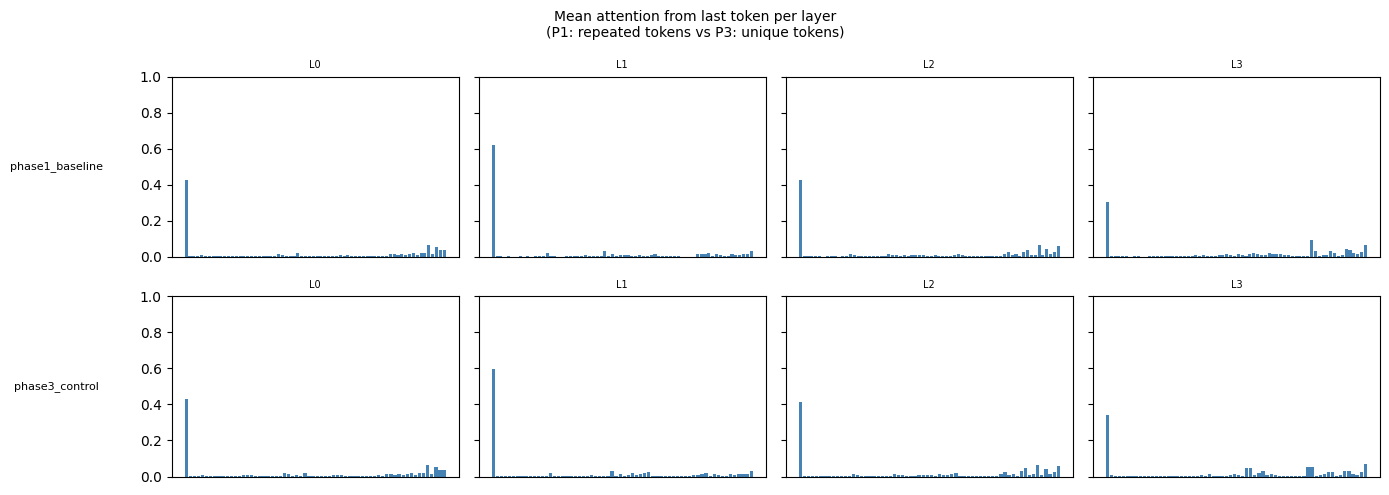

Saved: attention_p1_vs_p3.png


In [21]:
# ── Attention visualization on P1 vs P3 ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_attentions(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model_eager.device)

    with torch.no_grad():
        out = model_eager(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_attentions=True,
        )

    attentions = torch.stack(out.attentions)  # (n_layers, 1, n_heads, seq_len, seq_len)
    attentions = attentions.squeeze(1)         # (n_layers, n_heads, seq_len, seq_len)
    return attentions, inputs["input_ids"][0]

def plot_attention_last_token(attentions, input_ids, title, ax_row, axes):
    """Plot per-layer mean attention from the LAST token (generation position)."""
    n_layers = attentions.shape[0]
    tokens = [tokenizer.decode([t]) for t in input_ids]

    # Mean over heads, attention FROM last token TO all input tokens
    last_tok_attn = attentions[:, :, -1, :].mean(dim=1)  # (n_layers, seq_len)
    last_tok_attn = last_tok_attn.cpu().float().numpy()

    for layer_idx, ax in enumerate(ax_row):
        ax.bar(range(len(tokens)), last_tok_attn[layer_idx], color="steelblue")
        ax.set_title(f"L{layer_idx}", fontsize=7)
        ax.set_xticks([])
        ax.set_ylim(0, 1)

    axes[0].set_ylabel(title, fontsize=8, rotation=0, labelpad=60, va="center")

# Sample every 4th layer to keep plot manageable (Llama-3.2-1B has 16 layers)
LAYERS_TO_PLOT = list(range(0, 16, 4))   # layers 0, 4, 8, 12

fig, axes = plt.subplots(
    2, len(LAYERS_TO_PLOT),
    figsize=(14, 5),
    sharey=True
)
fig.suptitle("Mean attention from last token per layer\n(P1: repeated tokens vs P3: unique tokens)", fontsize=10)

for row_idx, phase_key in enumerate(["phase1_baseline", "phase3_control"]):
    attentions, input_ids = get_attentions(PROMPTS[phase_key]["text"])
    selected = attentions[LAYERS_TO_PLOT]   # only the sampled layers
    plot_attention_last_token(selected, input_ids, phase_key, axes[row_idx], axes[row_idx])

plt.tight_layout()
plt.savefig("attention_p1_vs_p3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: attention_p1_vs_p3.png")

In [22]:
# ── Extract and save full attention data to JSON ──────────────────────────
import json
import numpy as np

def get_attention_stats(prompt_text, phase_key):
    """
    Returns per-layer, per-head attention stats from the last token.
    Saves everything needed for offline analysis.
    """
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model_eager.device)

    input_ids = inputs["input_ids"][0]
    tokens    = [tokenizer.decode([t]) for t in input_ids]
    seq_len   = len(tokens)

    with torch.no_grad():
        out = model_eager(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_attentions=True,
        )

    # attentions: (n_layers, n_heads, seq_len, seq_len)
    attentions = torch.stack(out.attentions).squeeze(1).cpu().float()
    n_layers, n_heads, _, _ = attentions.shape

    # Attention FROM last token TO every input position
    last_tok = attentions[:, :, -1, :]  # (n_layers, n_heads, seq_len)

    # ── Per-layer, per-head: full attention vector over positions
    per_head = last_tok.numpy().tolist()  # [layer][head][pos]

    # ── Per-layer: mean over heads
    mean_over_heads = last_tok.mean(dim=1).numpy().tolist()  # [layer][pos]

    # ── Per-layer: entropy of mean attention (measures spread vs spike)
    entropies = []
    for layer_idx in range(n_layers):
        attn = last_tok[layer_idx].mean(dim=0)  # (seq_len,)
        attn = attn / (attn.sum() + 1e-9)
        entropy = -(attn * (attn + 1e-9).log()).sum().item()
        entropies.append(entropy)

    # ── Per-layer: which position has max attention (mean over heads)
    argmax_positions = last_tok.mean(dim=1).argmax(dim=-1).numpy().tolist()
    argmax_tokens    = [tokens[p] for p in argmax_positions]

    return {
        "phase"            : phase_key,
        "prompt"           : prompt_text,
        "tokens"           : tokens,
        "seq_len"          : seq_len,
        "n_layers"         : n_layers,
        "n_heads"          : n_heads,
        "per_head_attn"    : per_head,          # [layer][head][pos]  — full data
        "mean_attn"        : mean_over_heads,   # [layer][pos]
        "entropy_per_layer": entropies,         # [layer]  scalar
        "argmax_pos"       : argmax_positions,  # [layer]  int
        "argmax_token"     : argmax_tokens,     # [layer]  str
    }


# ── Run for P1 and P3 ─────────────────────────────────────────────────────
attention_data = {}

for phase_key in ["phase1_baseline", "phase2_anomaly", "phase3_control"]:
    print(f"Extracting attention: {phase_key}...")
    stats = get_attention_stats(PROMPTS[phase_key]["text"], phase_key)
    attention_data[phase_key] = stats

    print(f"  seq_len={stats['seq_len']}  layers={stats['n_layers']}  heads={stats['n_heads']}")
    print(f"  entropy by layer: {[f'{e:.3f}' for e in stats['entropy_per_layer']]}")
    print(f"  argmax token by layer: {stats['argmax_token']}\n")


# ── Save to JSON ──────────────────────────────────────────────────────────
save_path = "attention_data.json"

# per_head_attn is float32 list-of-lists — JSON-serializable as-is
with open(save_path, "w") as f:
    json.dump(attention_data, f, indent=2)

print(f"Saved to {save_path}")
print(f"Keys per phase: {list(attention_data['phase1_baseline'].keys())}")

Extracting attention: phase1_baseline...
  seq_len=68  layers=28  heads=24
  entropy by layer: ['2.811', '1.593', '0.760', '1.350', '2.048', '1.894', '1.830', '2.228', '2.693', '2.506', '2.618', '2.821', '3.070', '2.889', '2.645', '2.122', '1.836', '0.953', '1.070', '1.154', '1.304', '0.769', '0.961', '1.419', '1.271', '1.003', '1.862', '1.636']
  argmax token by layer: ['<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>', '<|begin_of_text|>']

Extracting attention: phase2_anomaly.

In [23]:
# ── Re-analyze attention data focused on word-list tokens only ────────────
import json
import numpy as np

with open("attention_data.json") as f:
    attention_data = json.load(f)

def find_word_list_span(tokens, phase_key):
    """
    Find the start/end indices of the word-list tokens in the full sequence.
    The list ends just before the period+EOT, and starts after the prompt text.
    We locate by finding the first content word token.
    """
    # Content words we expect in each phase
    markers = {
        "phase1_baseline": "apple",
        "phase2_anomaly":  "apple",
        "phase3_control":  "dog",
    }
    marker = markers[phase_key]
    # Find first occurrence of the marker token (strip leading space)
    for i, t in enumerate(tokens):
        if t.strip() == marker:
            start = i
            break

    # End: find the period token after the list
    for i in range(start, len(tokens)):
        if "." in tokens[i]:
            end = i   # exclusive
            break
    else:
        end = len(tokens) - 1

    return start, end


print("=" * 70)
print("ATTENTION ANALYSIS — word-list tokens only (BOS/prompt masked out)")
print("=" * 70)

summary = {}

for phase_key, data in attention_data.items():
    tokens   = data["tokens"]
    n_layers = data["n_layers"]
    n_heads  = data["n_heads"]

    start, end = find_word_list_span(tokens, phase_key)
    word_tokens = tokens[start:end]
    print(f"\n[{phase_key}]")
    print(f"  Word-list span : positions {start}–{end-1}")
    print(f"  Word tokens    : {word_tokens}")

    # per_head_attn: [layer][head][pos] — slice to word-list positions only
    per_head = np.array(data["per_head_attn"])  # (n_layers, n_heads, seq_len)
    word_attn = per_head[:, :, start:end]        # (n_layers, n_heads, n_words)

    # Renormalize over word positions only (so they sum to 1 within the span)
    word_attn_norm = word_attn / (word_attn.sum(axis=-1, keepdims=True) + 1e-9)

    # Mean over heads per layer: (n_layers, n_words)
    mean_word_attn = word_attn_norm.mean(axis=1)

    # Entropy of attention over word positions per layer
    entropies = []
    for l in range(n_layers):
        a = mean_word_attn[l]
        a = a / (a.sum() + 1e-9)
        h = -(a * np.log(a + 1e-9)).sum()
        entropies.append(round(float(h), 4))

    # Which word position gets max attention per layer
    argmax_word_pos = mean_word_attn.argmax(axis=-1).tolist()
    argmax_word_tok = [word_tokens[p] for p in argmax_word_pos]

    # Uniformity score: ratio of min/max attention over word positions (mean over layers)
    # 1.0 = perfectly uniform, 0.0 = all mass on one token
    uniformity = (mean_word_attn.min(axis=-1) / (mean_word_attn.max(axis=-1) + 1e-9)).mean()

    print(f"  Entropy by layer (word span): {entropies}")
    print(f"  Argmax word token by layer  : {argmax_word_tok}")
    print(f"  Mean uniformity score       : {uniformity:.4f}  (1=uniform, 0=spiked)")

    summary[phase_key] = {
        "word_span"       : [start, end],
        "word_tokens"     : word_tokens,
        "entropy_per_layer": entropies,
        "argmax_word_token": argmax_word_tok,
        "mean_uniformity" : float(uniformity),
        "mean_word_attn"  : mean_word_attn.tolist(),  # (n_layers, n_words)
    }

# ── Save focused summary ──────────────────────────────────────────────────
with open("attention_word_span_analysis.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved: attention_word_span_analysis.json")

# ── Print comparison table ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY — mean entropy and uniformity over word-list span")
print("=" * 70)
print(f"  {'Phase':<25} {'Mean entropy':>14}  {'Uniformity':>12}")
print("  " + "-" * 54)
for phase_key, s in summary.items():
    me = np.mean(s["entropy_per_layer"])
    print(f"  {phase_key:<25} {me:>14.4f}  {s['mean_uniformity']:>12.4f}")

ATTENTION ANALYSIS — word-list tokens only (BOS/prompt masked out)

[phase1_baseline]
  Word-list span : positions 36–52
  Word tokens    : ['apple', '"', ' appears', ' in', ' this', ' list', ':', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple']
  Entropy by layer (word span): [2.7404, 2.6106, 2.3138, 2.285, 2.2841, 2.2463, 2.2736, 2.3987, 2.4057, 2.5395, 2.5236, 2.5687, 2.6051, 2.7409, 2.7484, 2.7175, 2.734, 2.5939, 2.5824, 2.5158, 2.661, 2.5001, 2.5957, 2.4889, 2.3946, 2.3267, 2.5005, 2.6445]
  Argmax word token by layer  : [':', ':', ':', ' list', ':', ':', ':', ':', ':', ':', ':', ':', ':', ':', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple']
  Mean uniformity score       : 0.0897  (1=uniform, 0=spiked)

[phase2_anomaly]
  Word-list span : positions 36–52
  Word tokens    : ['apple', '"', ' appears', ' in', ' this', ' list', ':', ' apple', ' apple', ' app

In [24]:
def find_word_list_span(tokens, phase_key):
    """
    Locate the word-list tokens by finding the colon that ends the prompt
    instruction ('...in this list:'), then taking everything after it
    up to the period.
    """
    content_words = {
        "phase1_baseline": {"apple"},
        "phase2_anomaly":  {"apple", "banana"},
        "phase3_control":  {"dog", "cat", "car", "red", "blue",
                            "green", "house", "tree", "book", "pen"},
    }
    valid = content_words[phase_key]

    # Find the last colon before the word list starts
    # Then scan forward collecting only content word tokens
    colon_idx = None
    for i, t in enumerate(tokens):
        if t.strip() == ":":
            colon_idx = i

    # From the last colon onward, collect positions whose stripped token
    # is a known content word
    word_positions = []
    for i in range(colon_idx + 1, len(tokens)):
        if tokens[i].strip() in valid:
            word_positions.append(i)
        elif "." in tokens[i] and word_positions:
            break  # hit the period ending the list

    return word_positions  # list of exact positions, not a contiguous span


def get_word_attn(per_head_np, word_positions):
    """Slice and renormalize attention to word positions only."""
    # per_head_np: (n_layers, n_heads, seq_len)
    word_attn = per_head_np[:, :, word_positions]       # (n_layers, n_heads, n_words)
    word_attn_norm = word_attn / (word_attn.sum(axis=-1, keepdims=True) + 1e-9)
    return word_attn_norm


print("=" * 70)
print("ATTENTION ANALYSIS — word-list tokens only (FIXED span)")
print("=" * 70)

summary_fixed = {}

for phase_key, data in attention_data.items():
    tokens   = data["tokens"]
    n_layers = data["n_layers"]

    word_positions = find_word_list_span(tokens, phase_key)
    word_tokens    = [tokens[p] for p in word_positions]

    print(f"\n[{phase_key}]")
    print(f"  Word positions : {word_positions}")
    print(f"  Word tokens    : {word_tokens}")
    print(f"  Count          : {len(word_positions)}  (expected {data['seq_len']})")

    per_head      = np.array(data["per_head_attn"])          # (n_layers, n_heads, seq_len)
    word_attn_norm = get_word_attn(per_head, word_positions) # (n_layers, n_heads, n_words)
    mean_word_attn = word_attn_norm.mean(axis=1)             # (n_layers, n_words)

    entropies = []
    for l in range(n_layers):
        a = mean_word_attn[l]
        a = a / (a.sum() + 1e-9)
        h = -(a * np.log(a + 1e-9)).sum()
        entropies.append(round(float(h), 4))

    argmax_pos = mean_word_attn.argmax(axis=-1).tolist()
    argmax_tok = [word_tokens[p] for p in argmax_pos]
    uniformity = (mean_word_attn.min(axis=-1) /
                  (mean_word_attn.max(axis=-1) + 1e-9)).mean()

    print(f"  Entropy by layer: {entropies}")
    print(f"  Argmax token    : {argmax_tok}")
    print(f"  Uniformity      : {uniformity:.4f}")

    summary_fixed[phase_key] = {
        "word_positions"   : word_positions,
        "word_tokens"      : word_tokens,
        "entropy_per_layer": entropies,
        "argmax_word_token": argmax_tok,
        "mean_uniformity"  : float(uniformity),
        "mean_word_attn"   : mean_word_attn.tolist(),
    }

with open("attention_word_span_fixed.json", "w") as f:
    json.dump(summary_fixed, f, indent=2)
print("\nSaved: attention_word_span_fixed.json")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"  {'Phase':<25} {'Mean entropy':>14}  {'Uniformity':>12}")
print("  " + "-" * 54)
for phase_key, s in summary_fixed.items():
    me = np.mean(s["entropy_per_layer"])
    print(f"  {phase_key:<25} {me:>14.4f}  {s['mean_uniformity']:>12.4f}")

ATTENTION ANALYSIS — word-list tokens only (FIXED span)

[phase1_baseline]
  Word positions : [43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
  Word tokens    : [' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple']
  Count          : 10  (expected 68)
  Entropy by layer: [2.2813, 2.214, 1.8097, 1.9957, 2.1274, 1.9294, 1.9914, 2.2377, 2.2103, 2.2461, 2.1366, 2.0913, 2.0485, 2.2775, 2.2072, 2.2351, 2.2812, 2.148, 2.1517, 2.0889, 2.2134, 2.1843, 2.2082, 2.1047, 2.0402, 2.0605, 2.1463, 2.1691]
  Argmax token    : [' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple', ' apple']
  Uniformity      : 0.2342

[phase2_anomaly]
  Word positions : [43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
  Word tokens    : [' apple', ' apple', ' apple', ' apple',

## Linear Probe

In [25]:
# ── Linear probe: does any layer encode the correct count? ────────────────
# Collect last-token residual stream activations across all three phases,
# then train a linear regression per layer to predict the correct answer.
# If no layer achieves low error, the count is not linearly encoded anywhere.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np

def get_hidden_states(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model_eager.device)

    with torch.no_grad():
        out = model_eager(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_hidden_states=True,
        )

    # hidden_states: tuple of (n_layers+1) each (1, seq_len, hidden_dim)
    # index 0 = embedding, 1..16 = after each transformer layer
    # take last token position from each layer
    hidden = torch.stack(out.hidden_states)  # (n_layers+1, 1, seq_len, hidden_dim)
    last_tok = hidden[:, 0, -1, :]           # (n_layers+1, hidden_dim)
    return last_tok.cpu().float().numpy()


# Build dataset: vary the count by using different list lengths
# Generate prompts with 5, 6, 7, 8, 9, 10, 11, 12 apples
probe_prompts = []
probe_labels  = []

for n in range(3, 16):
    text = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    probe_prompts.append(text)
    probe_labels.append(n)

print(f"Probe dataset: {len(probe_prompts)} prompts, counts {probe_labels}")

# Collect activations
all_hidden = []  # (n_prompts, n_layers+1, hidden_dim)
for prompt in probe_prompts:
    h = get_hidden_states(prompt)
    all_hidden.append(h)

all_hidden = np.stack(all_hidden)  # (n_prompts, n_layers+1, hidden_dim)
labels     = np.array(probe_labels, dtype=float)

n_layers_plus1 = all_hidden.shape[1]

# Per-layer linear probe (Ridge regression, leave-one-out)
print("\nLayer-wise linear probe (Ridge, LOO cross-val):")
print(f"  {'Layer':>6}  {'LOO MAE':>10}  {'LOO R²':>10}")
print("  " + "-" * 32)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score

loo = LeaveOneOut()
layer_maes = []
layer_r2s  = []

for layer_idx in range(n_layers_plus1):
    X = all_hidden[:, layer_idx, :]  # (n_prompts, hidden_dim)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    preds = np.zeros(len(labels))
    for train_idx, test_idx in loo.split(X_scaled):
        clf = Ridge(alpha=1.0)
        clf.fit(X_scaled[train_idx], labels[train_idx])
        preds[test_idx] = clf.predict(X_scaled[test_idx])

    mae = mean_absolute_error(labels, preds)
    r2  = r2_score(labels, preds)
    layer_maes.append(mae)
    layer_r2s.append(r2)
    label = "embed" if layer_idx == 0 else f"L{layer_idx:02d}"
    print(f"  {label:>6}  {mae:>10.4f}  {r2:>10.4f}")

# Save probe results
probe_results = {
    "labels"    : probe_labels,
    "layer_maes": layer_maes,
    "layer_r2s" : layer_r2s,
}
with open("probe_results.json", "w") as f:
    json.dump(probe_results, f, indent=2)
print("\nSaved: probe_results.json")

Probe dataset: 13 prompts, counts [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Layer-wise linear probe (Ridge, LOO cross-val):
   Layer     LOO MAE      LOO R²
  --------------------------------
   embed      3.5000     -0.1736
     L01      0.0797      0.9989
     L02      0.1013      0.9977
     L03      0.1248      0.9977
     L04      0.1333      0.9965
     L05      0.1252      0.9951
     L06      0.1233      0.9963
     L07      0.1383      0.9961
     L08      0.1536      0.9955
     L09      0.1695      0.9941
     L10      0.1865      0.9918
     L11      0.2256      0.9921
     L12      0.1638      0.9942
     L13      0.1981      0.9911
     L14      0.2467      0.9849
     L15      0.3291      0.9654
     L16      0.2425      0.9821
     L17      0.2646      0.9807
     L18      0.1899      0.9889
     L19      0.2240      0.9850
     L20      0.2725      0.9748
     L21      0.2688      0.9755
     L22      0.2549      0.9817
     L23      0.2621      0.9825
     L24   

In [26]:
# ── Probe Experiment 2: repeated vs unique tokens at fixed length ─────────
# Test whether the probe accuracy DIFFERS between repeated and unique tokens
# at the same sequence length (n=10). If the probe works equally well on both,
# the representation encodes count regardless of token identity —
# confirming the failure is in output routing, not representation.

def get_hidden_states_from_text(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)
    with torch.no_grad():
        out = model_eager(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_hidden_states=True,
        )
    hidden = torch.stack(out.hidden_states)  # (n_layers+1, 1, seq_len, hidden_dim)
    return hidden[:, 0, -1, :].cpu().float().numpy()  # (n_layers+1, hidden_dim)


# Build two parallel probe datasets at varying n:
# A) repeated tokens (all apple)
# B) unique tokens (cycling through a fixed vocab)
unique_vocab = ["dog", "cat", "car", "red", "blue", "green",
                "house", "tree", "book", "pen", "fish", "cup", "hat"]

repeated_prompts, unique_prompts, probe_ns = [], [], []

for n in range(3, 14):  # 3–13, safe range for unique vocab
    # Repeated
    repeated_prompts.append(
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    # Unique
    unique_prompts.append(
        "Count the number of words in this list: "
        + " ".join(unique_vocab[:n])
        + ". Respond only with the integer, nothing else."
    )
    probe_ns.append(n)

labels = np.array(probe_ns, dtype=float)

print("Collecting activations for repeated and unique token probes...")
hidden_repeated = np.stack([get_hidden_states_from_text(p) for p in repeated_prompts])
hidden_unique   = np.stack([get_hidden_states_from_text(p) for p in unique_prompts])
# shapes: (n_prompts, n_layers+1, hidden_dim)

# LOO Ridge probe for both conditions
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

loo = LeaveOneOut()

def run_loo_probe(hidden_array, labels):
    n_layers = hidden_array.shape[1]
    maes, r2s = [], []
    for layer_idx in range(n_layers):
        X = StandardScaler().fit_transform(hidden_array[:, layer_idx, :])
        preds = np.zeros(len(labels))
        for train_idx, test_idx in loo.split(X):
            clf = Ridge(alpha=1.0)
            clf.fit(X[train_idx], labels[train_idx])
            preds[test_idx] = clf.predict(X[test_idx])
        maes.append(mean_absolute_error(labels, preds))
        r2s.append(r2_score(labels, preds))
    return maes, r2s

print("Running probes...")
maes_rep, r2s_rep = run_loo_probe(hidden_repeated, labels)
maes_uniq, r2s_uniq = run_loo_probe(hidden_unique, labels)

print(f"\n{'Layer':>6}  {'MAE(repeat)':>12}  {'R²(repeat)':>11}  {'MAE(unique)':>12}  {'R²(unique)':>11}  {'ΔMAE':>8}")
print("-" * 70)
for i, (mr, rr, mu, ru) in enumerate(zip(maes_rep, r2s_rep, maes_uniq, r2s_uniq)):
    label = "embed" if i == 0 else f"L{i:02d}"
    delta = mr - mu
    print(f"{label:>6}  {mr:>12.4f}  {rr:>11.4f}  {mu:>12.4f}  {ru:>11.4f}  {delta:>+8.4f}")

# Save
probe2 = {
    "ns": probe_ns, "labels": probe_ns,
    "repeated": {"maes": maes_rep, "r2s": r2s_rep},
    "unique":   {"maes": maes_uniq, "r2s": r2s_uniq},
}
with open("probe_repeated_vs_unique.json", "w") as f:
    json.dump(probe2, f, indent=2)
print("\nSaved: probe_repeated_vs_unique.json")

Running probes...

 Layer   MAE(repeat)   R²(repeat)   MAE(unique)   R²(unique)      ΔMAE
----------------------------------------------------------------------
 embed        3.0000      -0.2100        3.0000      -0.2100   +0.0000
   L01        0.0718       0.9988        0.1326       0.9968   -0.0608
   L02        0.0873       0.9986        0.1762       0.9944   -0.0889
   L03        0.0929       0.9983        0.1878       0.9937   -0.0949
   L04        0.1144       0.9976        0.1605       0.9934   -0.0462
   L05        0.1154       0.9958        0.1993       0.9888   -0.0839
   L06        0.1390       0.9948        0.2410       0.9837   -0.1019
   L07        0.1654       0.9918        0.2704       0.9815   -0.1049
   L08        0.1751       0.9912        0.2751       0.9791   -0.1000
   L09        0.1938       0.9887        0.3529       0.9730   -0.1591
   L10        0.2346       0.9850        0.4505       0.9618   -0.2159
   L11        0.2476       0.9872        0.4157       0.96

## logit lens

In [27]:
# ── Logit lens: project residual stream through unembedding per layer ─────
# For each layer, project hidden state at last token → vocab logits → 
# top predicted number. Shows where "8" takes over from the correct count.

def logit_lens(prompt_text, top_k=5):
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

    with torch.no_grad():
        out = model_eager(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            output_hidden_states=True,
        )

    # Unembedding matrix: (vocab_size, hidden_dim)
    unembed = model_eager.lm_head.weight  # (vocab_size, hidden_dim)
    # Apply final layernorm before unembedding
    norm    = model_eager.model.norm

    results = []
    hidden_states = out.hidden_states  # tuple: (n_layers+1,) each (1, seq_len, hidden_dim)

    for layer_idx, h in enumerate(hidden_states):
        last = h[0, -1, :]           # (hidden_dim,)
        last_normed = norm(last.unsqueeze(0).unsqueeze(0)).squeeze()
        logits = unembed @ last_normed  # (vocab_size,)
        topk   = logits.topk(top_k)
        top_tokens = [tokenizer.decode([idx]) for idx in topk.indices]
        top_probs  = topk.values.softmax(dim=-1).tolist()
        # Find top digit token specifically
        digit_logits = {str(n): logits[tokenizer.encode(str(n), add_special_tokens=False)[0]].item()
                        for n in range(1, 20)}
        top_digit = max(digit_logits, key=digit_logits.get)
        results.append({
            "layer"     : "embed" if layer_idx == 0 else f"L{layer_idx:02d}",
            "top_tokens": top_tokens,
            "top_probs" : [round(p, 4) for p in top_probs],
            "top_digit" : top_digit,
        })
    return results


print("=" * 65)
print("LOGIT LENS — where does '8' take over from correct count?")
print("=" * 65)

for phase_key in ["phase1_baseline", "phase3_control"]:
    print(f"\n[{phase_key}]  correct={PROMPTS[phase_key]['expected']}")
    print(f"  {'Layer':>6}  {'Top digit':>10}  {'Top-5 tokens'}")
    print("  " + "-" * 55)
    lens = logit_lens(PROMPTS[phase_key]["text"])
    for r in lens:
        print(f"  {r['layer']:>6}  {r['top_digit']:>10}  {r['top_tokens']}")

LOGIT LENS — where does '8' take over from correct count?

[phase1_baseline]  correct=10
   Layer   Top digit  Top-5 tokens
  -------------------------------------------------------
   embed           1  ['\n\n', '\n', '\n\n\n', ' \n\n', '"\n\n']
     L01          17  ['\n\n', '"\n\n', '_\n\n', '์\n\n', '()\n\n']
     L02          17  ['\n\n', '/\n\n', '*\n\n', '”\n\n', '"\n\n']
     L03          17  ['\n\n', '\t\n\n', 'ря', 'kah', '/\n\n']
     L04          17  ['opa', ' Monroe', 'ulan', 'ム', 'CORD']
     L05          18  ['yal', 'highlight', ' highlighting', '்�', 'Highlight']
     L06          19  ['்�', ' Acad', 'veal', ' tailor', 'ustom']
     L07          19  [' tailor', ' customization', ' Acad', ' customized', ' analyzing']
     L08          19  ['zon', ' towel', ' Playground', ' Acad', 'fine']
     L09          18  ['òi', ' invitation', ' Invitation', ' spawning', 'xon']
     L10          17  ['arium', 'inus', 'istributor', 'ylinder', 'ahkan']
     L11          14  ['oine', 'i

In [28]:
# ── Clear all lingering hooks before doing anything ───────────────────────
def remove_all_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()

remove_all_hooks(model_eager)
print("All hooks cleared.")

All hooks cleared.


In [29]:
def decompose_layer(prompt_text, layer_idx):
    messages = [{"role": "user", "content": prompt_text}]
    inputs   = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

    cache = {}

    # Hook on the full decoder layer to get before/after states
    # Use input_layernorm as proxy for residual before attention
    def hook_pre_layer(module, input, output):
        # input[0] is hidden_states entering the full decoder layer
        # shape: (1, seq_len, hidden_dim)
        if isinstance(input, tuple) and len(input) > 0:
            h = input[0]
        else:
            h = input
        if isinstance(h, torch.Tensor):
            cache["h_before"] = h[0, -1, :].detach().clone()

    # Hook after attention sublayer by hooking the layer's post-attn residual
    # We hook the mlp input_layernorm — its input is residual after attention
    def hook_post_attn(module, input, output):
        if isinstance(input, tuple) and len(input) > 0:
            h = input[0]
        else:
            h = input
        if isinstance(h, torch.Tensor):
            cache["h_post_attn"] = h[0, -1, :].detach().clone()

    # Hook after full layer
    def hook_post_layer(module, input, output):
        h = output[0] if isinstance(output, tuple) else output
        cache["h_post_layer"] = h[0, -1, :].detach().clone()

    layer = model_eager.model.layers[layer_idx - 1]

    handle1 = layer.register_forward_pre_hook(hook_pre_layer)
    handle2 = layer.post_feedforward_layernorm.register_forward_pre_hook(hook_post_attn) \
              if hasattr(layer, 'post_feedforward_layernorm') \
              else layer.mlp.register_forward_pre_hook(hook_post_attn)
    handle3 = layer.register_forward_hook(hook_post_layer)

    with torch.no_grad():
        model_eager(**inputs)

    handle1.remove()
    handle2.remove()
    handle3.remove()

    # Verify we got all three
    if len(cache) < 3:
        print(f"  Warning: only got {list(cache.keys())} for L{layer_idx}")

    results = {}
    for name, h in cache.items():
        td, top5, _ = logit_lens_single(h)
        results[name] = {"top_digit": td, "top5": top5}

    return results


# ── Inspect layer structure first to confirm hook targets ─────────────────
print("Layer submodule names:")
for name, _ in model_eager.model.layers[0].named_children():
    print(f"  {name}")

Layer submodule names:
  self_attn
  mlp
  input_layernorm
  post_attention_layernorm


## MLP Decomposition

In [38]:
# ── MLP vs Attention decomposition ────────────────────────────────────────
LOCKIN_LAYER = 26  # 3B primary writer — change per model

remove_all_hooks(model_eager)

# Read attractor from behavioral results — works for any model
known_attractor = str(all_results["phase1_baseline"][0]["predicted"])
print(f"Tracking attractor: '{known_attractor}' (from behavioral results)")


def logit_lens_single(hidden_state):
    norm    = model_eager.model.norm
    unembed = model_eager.lm_head.weight
    with torch.no_grad():
        normed = norm(hidden_state.unsqueeze(0).unsqueeze(0)).squeeze()
        logits = unembed @ normed
    candidates = {}
    for n in range(1, 20):
        ids = tokenizer.encode(str(n), add_special_tokens=False)
        if len(ids) == 1:
            candidates[str(n)] = logits[ids[0]].item()
    top_digit = max(candidates, key=candidates.get)
    top5      = [tokenizer.decode([i]) for i in logits.topk(5).indices]
    return top_digit, top5


def decompose_layer(prompt_text, layer_idx):
    messages = [{"role": "user", "content": prompt_text}]
    inputs   = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

    cache = {}
    layer = model_eager.model.layers[layer_idx - 1]

    def hook_pre_layer(module, input):
        h = input[0] if isinstance(input, tuple) else input
        if isinstance(h, torch.Tensor):
            cache["h_before"] = h[0, -1, :].detach().clone()

    def hook_post_attn(module, input, output):
        h = input[0] if isinstance(input, tuple) else input
        if isinstance(h, torch.Tensor):
            cache["h_post_attn"] = h[0, -1, :].detach().clone()

    def hook_post_layer(module, input, output):
        h = output[0] if isinstance(output, tuple) else output
        if isinstance(h, torch.Tensor):
            cache["h_post_layer"] = h[0, -1, :].detach().clone()

    h1 = layer.register_forward_pre_hook(hook_pre_layer)
    h2 = layer.post_attention_layernorm.register_forward_hook(hook_post_attn)
    h3 = layer.register_forward_hook(hook_post_layer)

    with torch.no_grad():
        model_eager(**inputs)

    h1.remove(); h2.remove(); h3.remove()

    if len(cache) < 3:
        print(f"  Warning L{layer_idx}: only captured {list(cache.keys())}")

    return {
        name: {"top_digit": logit_lens_single(h)[0],
               "top5"     : logit_lens_single(h)[1]}
        for name, h in cache.items()
    }


def get_writer(before, post_attn, post_mlp, target):
    """Determine which component introduced or removed the target digit."""
    if before != target and post_attn == target:
        return "ATTENTION"
    elif post_attn != target and post_mlp == target:
        return "MLP"
    elif before == target and post_attn != target:
        return "ATTN ERASES"
    elif post_attn == target and post_mlp != target:
        return "MLP ERASES"
    elif before == target and post_attn == target and post_mlp == target:
        return "(stable)"
    else:
        return "-"


# ── Set CRITICAL_LAYERS in cell 1 after reading logit lens output ──────────
# 1B: CRITICAL_LAYERS = [11, 12, 13, 14, 15, 16]  (lock-in at L14)
# 3B: CRITICAL_LAYERS = [24, 25, 26, 27, 28]       (lock-in at L24-L28)
# Qwen: set after running logit lens

assert CRITICAL_LAYERS is not None, \
    "Set CRITICAL_LAYERS in cell 1 after running logit lens"

n_layers = model_eager.config.num_hidden_layers
print(f"\n{'='*72}")
print(f"MLP vs ATTENTION DECOMPOSITION — {MODEL_NAME}")
print(f"Attractor: '{known_attractor}' | Layers: {CRITICAL_LAYERS} / {n_layers} total")
print(f"{'='*72}")

decomp_results = {}

for phase_key in ["phase1_baseline", "phase3_control"]:
    # For P3, track what the model actually outputs (may differ from P1 attractor)
    phase_attractor = str(all_results[phase_key][0]["predicted"])

    print(f"\n[{phase_key}]  tracking: '{phase_attractor}'")
    print(f"  {'Layer':>6}  {'Before':>10}  {'Post-attn':>10}  "
          f"{'Post-MLP':>10}  Writer")
    print("  " + "-" * 58)

    for layer_idx in CRITICAL_LAYERS:
        remove_all_hooks(model_eager)
        r = decompose_layer(PROMPTS[phase_key]["text"], layer_idx)

        before    = r.get("h_before",    {}).get("top_digit", "?")
        post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
        post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
        writer    = get_writer(before, post_attn, post_mlp, phase_attractor)

        print(f"  L{layer_idx:02d}    {before:>10}  {post_attn:>10}  "
              f"{post_mlp:>10}  {writer}")

        decomp_results[f"{phase_key}_L{layer_idx:02d}"] = {
            "phase"      : phase_key,
            "layer"      : layer_idx,
            "attractor"  : phase_attractor,
            "h_before"   : r.get("h_before",    {}),
            "h_post_attn": r.get("h_post_attn", {}),
            "h_post_layer": r.get("h_post_layer",{}),
        }

save_path = f"mlp_attn_decomp_{MODEL_NAME.split('/')[-1]}.json"
with open(save_path, "w") as f:
    json.dump(decomp_results, f, indent=2)
print(f"\nSaved: {save_path}")

Tracking attractor: '14' (from behavioral results)

MLP vs ATTENTION DECOMPOSITION — meta-llama/Llama-3.2-3B-Instruct
Attractor: '14' | Layers: [22, 23, 24, 25, 26, 27, 28] / 28 total

[phase1_baseline]  tracking: '14'
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------------
  L22             8           8          14  MLP
  L23            14          14           8  MLP ERASES
  L24             8           8          10  -
  L25            10          10          10  -
  L26            10          10          14  MLP
  L27            14          14          14  (stable)
  L28            14          14          14  (stable)

[phase3_control]  tracking: '11'
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------------
  L22             7           7           7  -
  L23             7           9          17  -
  L24            17           9          17  -
  L25            17   

In [40]:
# ── Per-n MLP decomposition at L26 (3B primary writer) ───────────────────
LOCKIN_LAYER = 26

wrong_answer = str(all_results["phase1_baseline"][0]["predicted"])

print(f"Per-n MLP decomposition at L{LOCKIN_LAYER} — tracking '{wrong_answer}'")
print(f"{'n':>4}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  {'Wrote wrong?':>14}")
print("-" * 56)

for n in [7, 8, 9, 10, 11, 12, 15]:
    prompt = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt, LOCKIN_LAYER)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    wrote     = (
        "YES" if post_attn != wrong_answer and post_mlp == wrong_answer
        else "already" if before == wrong_answer
        else "no"
    )
    print(f"{n:>4}  {before:>10}  {post_attn:>10}  {post_mlp:>10}  {wrote:>14}")

Per-n MLP decomposition at L26 — tracking '14'
   n      Before   Post-attn    Post-MLP    Wrote wrong?
--------------------------------------------------------
   7           6           6           7              no
   8           7           8           8              no
   9           8           8           8              no
  10          10          10          14             YES
  11          10          10          14             YES
  12          10          10          14             YES
  15          14          14          14         already


In [ ]:
# ── Zero-ablate MLP L14: does removing it fix the output? ─────────────────
# If MLP L14 is causally responsible for "8", zeroing its output should
# change the final prediction. This is the strongest causal claim you can make.
def get_top_digit(logits_1d):
    digs = {str(n): logits_1d[
                tokenizer.encode(str(n), add_special_tokens=False)[0]
            ].item() for n in range(1, 20)}
    return max(digs, key=digs.get)

def zero_ablate_mlp(prompt_text, layer_idx):
    """Run forward pass with MLP output at layer_idx zeroed out."""
    messages = [{"role": "user", "content": prompt_text}]
    inputs   = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

    def zero_mlp_hook(module, input, output):
        # Zero the MLP output — residual stream gets h + 0 instead of h + mlp(h)
        return torch.zeros_like(output)

    handle = model_eager.model.layers[layer_idx - 1].mlp.register_forward_hook(
        zero_mlp_hook
    )
    with torch.no_grad():
        out = model_eager(**inputs)
    handle.remove()

    logits    = out.logits[0, -1, :]
    top_digit = get_top_digit(logits)
    top5      = [tokenizer.decode([i]) for i in logits.topk(5).indices]
    return top_digit, top5


print("=" * 65)
print("ZERO-ABLATION OF MLP L14 — does removing it fix the output?")
print("=" * 65)
print(f"  {'n':>4}  {'Normal output':>14}  {'L14 MLP zeroed':>15}  {'Fixed?':>7}")
print("  " + "-" * 48)

ablation_results = {}

for n in [8, 9, 10, 11, 12, 15]:
    prompt = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    remove_all_hooks(model_eager)

    # Normal output
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        add_generation_prompt=True, return_tensors="pt", return_dict=True,
    ).to(model_eager.device)
    with torch.no_grad():
        normal_out = model_eager(**inputs)
    normal_digit = get_top_digit(normal_out.logits[0, -1, :])

    # Ablated output
    ablated_digit, ablated_top5 = zero_ablate_mlp(prompt, 14)
    fixed = "✓ YES" if ablated_digit == str(n) else "✗ no"

    print(f"  {n:>4}  {normal_digit:>14}  {ablated_digit:>15}  {fixed:>7}  {ablated_top5}")
    ablation_results[n] = {
        "n": n, "normal": normal_digit,
        "ablated": ablated_digit, "fixed": ablated_digit == str(n),
        "ablated_top5": ablated_top5,
    }

with open("mlp_l14_ablation.json", "w") as f:
    json.dump({str(k): v for k, v in ablation_results.items()}, f, indent=2)
print("\nSaved: mlp_l14_ablation.json")

ZERO-ABLATION OF MLP L14 — does removing it fix the output?
     n   Normal output   L14 MLP zeroed   Fixed?
  ------------------------------------------------
     8               8                8    ✓ YES  ['8', '7', '6', '9', '10']
     9               8                8     ✗ no  ['8', '7', '9', '16', '14']
    10               8                8     ✗ no  ['8', '16', '14', '9', '7']
    11               8               16     ✗ no  ['16', '14', '8', '12', '15']
    12               8               16     ✗ no  ['16', '14', '12', '15', '8']
    15               8               16     ✗ no  ['16', '14', '24', '12', '15']

Saved: mlp_l14_ablation.json


In [42]:
# Is L23 MLP always erasing "14" or only for specific n?
# Gap 1: Why does L23 MLP erase "14"?
# L22 writes "14", L23 immediately erases it. 
# You need to know if this is a general suppression pattern or specific to this input. 
# Run the same per-n decomposition at L23 to see what it's doing across n values:
LOCKIN_LAYER = 23

print(f"Per-n MLP decomposition at L23 — tracking erasure of '14'")
print(f"{'n':>4}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  {'Erased 14?':>12}")
print("-" * 54)

for n in [7, 8, 9, 10, 11, 12, 15]:
    prompt = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt, LOCKIN_LAYER)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    erased    = "YES" if before == "14" and post_mlp != "14" else "no"
    print(f"{n:>4}  {before:>10}  {post_attn:>10}  {post_mlp:>10}  {erased:>12}")

Per-n MLP decomposition at L23 — tracking erasure of '14'
   n      Before   Post-attn    Post-MLP    Erased 14?
------------------------------------------------------
   7           6           6           6            no
   8           6           6           6            no
   9           8           8           8            no
  10          14          14           8           YES
  11          10          10          10            no
  12          14          10          11           YES
  15          14          14          14            no


In [43]:
# Gap 2: What does L22 MLP do across n?
# L22 first writes "14" at n=10. Does it also fire for n=7–9 or only n≥10? This tells you whether L22 is the threshold setter:

LOCKIN_LAYER = 22

print(f"Per-n MLP decomposition at L22 — first writer of '14'")
print(f"{'n':>4}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  {'Wrote 14?':>11}")
print("-" * 53)

for n in [7, 8, 9, 10, 11, 12, 15]:
    prompt = (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt, LOCKIN_LAYER)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    wrote     = "YES" if post_attn != "14" and post_mlp == "14" else \
                "already" if before == "14" else "no"
    print(f"{n:>4}  {before:>10}  {post_attn:>10}  {post_mlp:>10}  {wrote:>11}")

Per-n MLP decomposition at L22 — first writer of '14'
   n      Before   Post-attn    Post-MLP    Wrote 14?
-----------------------------------------------------
   7           6           6           6           no
   8           6           6           6           no
   9           8           8           8           no
  10           8           8          14          YES
  11          14          14          10      already
  12          14          14          14      already
  15          12          12          14          YES


In [44]:
# Full layer sweep — track "14" across all layers for n=10
# Gap 3: Full layer sweep for "14" across all 28 layers
# Instead of checking individual layers you already suspect, get the complete picture of where "14" appears and disappears across all layers for a single n=10 prompt. 
# This gives you the full trajectory:
print("Full layer sweep — P1 n=10, tracking '14' across all layers")
print(f"{'Layer':>6}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  Writer")


prompt_n10 = (
    'Count the number of times "apple" appears in this list: '
    + " ".join(["apple"] * 10)
    + ". Respond only with the integer, nothing else."
)

full_sweep = {}
for layer_idx in range(1, 29):
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt_n10, layer_idx)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    writer    = get_writer(before, post_attn, post_mlp, "14")

    # Only print layers where something interesting happens
    if writer != "-" or "14" in [before, post_attn, post_mlp]:
        marker = " <--" if writer not in ["-", "(stable)"] else ""
        print(f"  L{layer_idx:02d}    {before:>10}  {post_attn:>10}  "
              f"{post_mlp:>10}  {writer}{marker}")

    full_sweep[layer_idx] = {
        "before": before, "post_attn": post_attn,
        "post_mlp": post_mlp, "writer": writer
    }

with open("full_layer_sweep_3b_n10.json", "w") as f:
    json.dump(full_sweep, f, indent=2)
print("\nSaved: full_layer_sweep_3b_n10.json")

Full layer sweep — P1 n=10, tracking '14' across all layers
 Layer      Before   Post-attn    Post-MLP  Writer
  L11            17           1          14  MLP <--
  L12            14          14           4  MLP ERASES <--
  L13             4          14          17  ATTENTION <--
  L22             8           8          14  MLP <--
  L23            14          14           8  MLP ERASES <--
  L26            10          10          14  MLP <--
  L27            14          14          14  (stable)
  L28            14          14          14  (stable)

Saved: full_layer_sweep_3b_n10.json


In [54]:
def logit_lens_full(prompt_text, top_k=5):
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt_text}],
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model_eager.device)

    unembed = model_eager.lm_head.weight
    norm    = model_eager.model.norm
    hidden_states = []

    # Collect embedding layer output first
    def hook_embed(module, input, output):
        hidden_states.append(output[0, -1, :].detach().clone())

    # Collect each decoder layer output
    def make_layer_hook(layer_idx):
        def hook(module, input, output):
            h = output[0] if isinstance(output, tuple) else output
            hidden_states.append(h[0, -1, :].detach().clone())
        return hook

    handles = []
    handles.append(model_eager.model.embed_tokens.register_forward_hook(hook_embed))
    for i, layer in enumerate(model_eager.model.layers):
        handles.append(layer.register_forward_hook(make_layer_hook(i)))

    with torch.no_grad():
        model_eager(**inputs)

    for h in handles:
        h.remove()

    results = []
    for layer_idx, h in enumerate(hidden_states):
        last_normed = norm(h.unsqueeze(0).unsqueeze(0)).squeeze()
        logits      = unembed @ last_normed

        candidates = {}
        for n in range(1, 20):
            ids = tokenizer.encode(str(n), add_special_tokens=False)
            if len(ids) == 1:
                candidates[str(n)] = logits[ids[0]].item()
        top_digit = max(candidates, key=candidates.get)
        top5      = [tokenizer.decode([i]) for i in logits.topk(top_k).indices]
        results.append({
            "layer"    : "embed" if layer_idx == 0 else f"L{layer_idx:02d}",
            "top_digit": top_digit,
            "top5"     : top5,
        })

    print(f"  Collected {len(results)} layers via hooks")
    return results


# Test
remove_all_hooks(model_eager)
lens_test = logit_lens_full(PROMPTS["phase1_baseline"]["text"])
print(f"Total layers: {len(lens_test)}")
for r in lens_test:
    print(f"  {r['layer']:>6}  {r['top_digit']:>10}  {r['top5']}")

  Collected 29 layers via hooks
Total layers: 29
   embed           1  ['\n\n', '\n', '\n\n\n', ' \n\n', '"\n\n']
     L01          17  ['\n\n', '"\n\n', '_\n\n', '์\n\n', '()\n\n']
     L02          17  ['\n\n', '/\n\n', '*\n\n', '”\n\n', '"\n\n']
     L03          17  ['\n\n', '\t\n\n', 'ря', 'kah', '/\n\n']
     L04          17  ['opa', ' Monroe', 'ulan', 'ム', 'CORD']
     L05          18  ['yal', 'highlight', ' highlighting', '்�', 'Highlight']
     L06          19  ['்�', ' Acad', 'veal', ' tailor', 'ustom']
     L07          19  [' tailor', ' customization', ' Acad', ' customized', ' analyzing']
     L08          19  ['zon', ' towel', ' Playground', ' Acad', 'fine']
     L09          18  ['òi', ' invitation', ' Invitation', ' spawning', 'xon']
     L10          17  ['arium', 'inus', 'istributor', 'ylinder', 'ahkan']
     L11          14  ['oine', 'inus', 'ema', 'fuel', 'oin']
     L12           4  ['inus', 'ema', '205', ' Dy', ' adaptation']
     L13          17  ['量', ' scoop', 

In [55]:
# ── Logit lens all three phases — 3B ─────────────────────────────────────
remove_all_hooks(model_eager)

lens_all = {}

for phase_key in ["phase1_baseline", "phase2_anomaly", "phase3_control"]:
    correct = PROMPTS[phase_key]["expected"]
    output  = all_results[phase_key][0]["predicted"]
    print(f"\n[{phase_key}]  correct={correct}  model outputs={output}")
    print(f"  {'Layer':>6}  {'Top digit':>10}  Top-5 tokens")
    print("  " + "-" * 55)

    remove_all_hooks(model_eager)
    lens = logit_lens_full(PROMPTS[phase_key]["text"])
    lens_all[phase_key] = lens

    for r in lens:
        print(f"  {r['layer']:>6}  {r['top_digit']:>10}  {r['top5']}")

with open(f"logit_lens_all_phases_{MODEL_NAME.split('/')[-1]}.json", "w") as f:
    json.dump(lens_all, f, indent=2)
print(f"\nSaved: logit_lens_all_phases_{MODEL_NAME.split('/')[-1]}.json")


[phase1_baseline]  correct=10  model outputs=14
   Layer   Top digit  Top-5 tokens
  -------------------------------------------------------
  Collected 29 layers via hooks
   embed           1  ['\n\n', '\n', '\n\n\n', ' \n\n', '"\n\n']
     L01          17  ['\n\n', '"\n\n', '_\n\n', '์\n\n', '()\n\n']
     L02          17  ['\n\n', '/\n\n', '*\n\n', '”\n\n', '"\n\n']
     L03          17  ['\n\n', '\t\n\n', 'ря', 'kah', '/\n\n']
     L04          17  ['opa', ' Monroe', 'ulan', 'ム', 'CORD']
     L05          18  ['yal', 'highlight', ' highlighting', '்�', 'Highlight']
     L06          19  ['்�', ' Acad', 'veal', ' tailor', 'ustom']
     L07          19  [' tailor', ' customization', ' Acad', ' customized', ' analyzing']
     L08          19  ['zon', ' towel', ' Playground', ' Acad', 'fine']
     L09          18  ['òi', ' invitation', ' Invitation', ' spawning', 'xon']
     L10          17  ['arium', 'inus', 'istributor', 'ylinder', 'ahkan']
     L11          14  ['oine', 'inus', 'e

In [56]:
# ── 3B mechanistic summary ────────────────────────────────────────────────
summary_3b = {
    "model": MODEL_NAME,
    "n_layers": 28,
    "p1_attractor": "14",
    "p2_attractor": "8",
    "p3_attractor": "11",
    "key_layers": {
        "L22": "MLP writes '14' for P1 (n>=10 repeated tokens); suppressed by banana in P2",
        "L23": "MLP erases '14' back to '8' for P1",
        "L26": "MLP final arbiter: reinstates '14' for P1, writes '11' for P3, bypassed for P2",
        "L27_L28": "stable — output locked"
    },
    "divergence_layer": "L22",
    "lock_in_layer": "L26",
    "lock_in_depth_pct": round(26/28, 3),
    "cross_scale_note": (
        "Matches 1B pattern: single late MLP block (L26/28=92.8%) "
        "as final arbiter, consistent with 1B L14/16=87.5%"
    )
}

with open(f"mechanistic_summary_3b.json", "w") as f:
    json.dump(summary_3b, f, indent=2)
print("Saved: mechanistic_summary_3b.json")
print("\n3B mechanistic analysis complete.")

Saved: mechanistic_summary_3b.json

3B mechanistic analysis complete.


## Paraphrase decomposition 

In [ ]:
# ── Simple paraphrase decomposition at L27 and L28 — 3B ──────────────────
simple_prompt = (
    'Count "apple" in: '
    "apple apple apple apple apple apple apple apple apple apple. "
    "Reply with just the number."
)

print(f"Simple paraphrase output: {all_results['phase1_baseline'][0]['predicted']}")
print(f"Decomposing at L27 and L28 for 'simple' paraphrase\n")
print(f"  {'Layer':>6}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  Writer")
print("  " + "-" * 52)

for layer_idx in [26, 27, 28]:
    remove_all_hooks(model_eager)
    r = decompose_layer(simple_prompt, layer_idx)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    writer    = get_writer(before, post_attn, post_mlp, "14")

    print(f"  L{layer_idx:02d}    {before:>10}  {post_attn:>10}  {post_mlp:>10}  {writer}")

Simple paraphrase output: 14
Decomposing at L27 and L28 for 'simple' paraphrase

   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------
  L26             8           8           8  -
  L27             8           8           8  -
  L28             8           8           8  -


In [ ]:
# Full layer sweep for 'simple' paraphrase — find where "14" appears
simple_prompt = (
    'Count "apple" in: '
    "apple apple apple apple apple apple apple apple apple apple. "
    "Reply with just the number."
)

print("Full layer sweep — 'simple' paraphrase, tracking '14'")
print(f"  {'Layer':>6}  {'Before':>10}  {'Post-attn':>10}  {'Post-MLP':>10}  Writer")
print("  " + "-" * 52)

for layer_idx in range(1, 29):
    remove_all_hooks(model_eager)
    r = decompose_layer(simple_prompt, layer_idx)

    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    writer    = get_writer(before, post_attn, post_mlp, "14")

    # Only print if 14 appears anywhere or writer is not neutral
    if "14" in [before, post_attn, post_mlp] or writer not in ["-"]:
        print(f"  L{layer_idx:02d}    {before:>10}  {post_attn:>10}  {post_mlp:>10}  {writer}")

Full layer sweep — 'simple' paraphrase, tracking '14'
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------
  L11            17          17          14  MLP
  L12            14          14           4  MLP ERASES
  L13             4          14          17  ATTENTION


In [ ]:
# ── Define required functions if not in session ───────────────────────────
import torch
import re
from typing import Optional

def make_inputs_eager(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    return tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

def remove_all_hooks(m):
    for module in m.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()

def logit_lens_single(hidden_state):
    norm    = model_eager.model.norm
    unembed = model_eager.lm_head.weight
    with torch.no_grad():
        normed = norm(hidden_state.unsqueeze(0).unsqueeze(0)).squeeze()
        logits = unembed @ normed
    candidates = {}
    for n in range(1, 20):
        ids = tokenizer.encode(str(n), add_special_tokens=False)
        if len(ids) == 1:
            candidates[str(n)] = logits[ids[0]].item()
    top_digit = max(candidates, key=candidates.get)
    top5      = [tokenizer.decode([i]) for i in logits.topk(5).indices]
    return top_digit, top5

def decompose_layer(prompt_text, layer_idx):
    inputs = make_inputs_eager(prompt_text)
    cache  = {}
    layer  = model_eager.model.layers[layer_idx - 1]

    def hook_pre_layer(module, input):
        h = input[0] if isinstance(input, tuple) else input
        if isinstance(h, torch.Tensor):
            cache["h_before"] = h[0, -1, :].detach().clone()

    def hook_post_attn(module, input, output):
        h = input[0] if isinstance(input, tuple) else input
        if isinstance(h, torch.Tensor):
            cache["h_post_attn"] = h[0, -1, :].detach().clone()

    def hook_post_layer(module, input, output):
        h = output[0] if isinstance(output, tuple) else output
        if isinstance(h, torch.Tensor):
            cache["h_post_layer"] = h[0, -1, :].detach().clone()

    h1 = layer.register_forward_pre_hook(hook_pre_layer)
    h2 = layer.post_attention_layernorm.register_forward_hook(hook_post_attn)
    h3 = layer.register_forward_hook(hook_post_layer)

    with torch.no_grad():
        model_eager(**inputs)

    h1.remove(); h2.remove(); h3.remove()

    return {
        name: {"top_digit": logit_lens_single(h)[0],
               "top5"     : logit_lens_single(h)[1]}
        for name, h in cache.items()
    }

def get_writer(before, post_attn, post_mlp, target):
    if before != target and post_attn == target:
        return "ATTENTION"
    elif post_attn != target and post_mlp == target:
        return "MLP"
    elif before == target and post_attn != target:
        return "ATTN ERASES"
    elif post_attn == target and post_mlp != target:
        return "MLP ERASES"
    elif before == target and post_attn == target and post_mlp == target:
        return "(stable)"
    else:
        return "-"

def get_top_digit(logits_1d):
    candidates = {}
    for n in range(1, 20):
        ids = tokenizer.encode(str(n), add_special_tokens=False)
        if len(ids) == 1:
            candidates[str(n)] = logits_1d[ids[0]].item()
    return max(candidates, key=candidates.get) if candidates else "?"

def extract_count(raw_output: str) -> Optional[int]:
    match = re.search(r'\b(\d+)\b', raw_output.strip())
    return int(match.group(1)) if match else None

In [ ]:
# ── Diagnostic: simple paraphrase mechanistic investigation ───────────────

PARAPHRASE_PROMPTS_3B = {
    "original": (
        'Count the number of times "apple" appears in this list: '
        "apple apple apple apple apple apple apple apple apple apple. "
        "Respond only with the integer, nothing else."
    ),
    "how_many": (
        'How many times does the word "apple" appear in the following list: '
        "apple apple apple apple apple apple apple apple apple apple? "
        "Answer with a single integer, nothing else."
    ),
    "list_first": (
        "List: apple apple apple apple apple apple apple apple apple apple\n"
        'How many times does "apple" appear? Single integer only.'
    ),
    "tally": (
        'Tally the occurrences of "apple" in this sequence: '
        "apple apple apple apple apple apple apple apple apple apple. "
        "Output only the count as an integer."
    ),
    "simple": (
        'Count "apple" in: '
        "apple apple apple apple apple apple apple apple apple apple. "
        "Reply with just the number."
    ),
}

# ── Diagnostic 1: L11 decomposition across all paraphrases ────────────────
print("=" * 65)
print("DIAGNOSTIC 1 — L11 MLP behavior across all paraphrases")
print("Does L11 write '14' for 'simple' only or for others too?")
print("=" * 65)
print(f"  {'Paraphrase':<15}  {'Before':>10}  {'Post-attn':>10}  "
      f"{'Post-MLP':>10}  Writer")
print("  " + "-" * 60)

for pname, prompt in PARAPHRASE_PROMPTS_3B.items():
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt, 11)
    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    writer    = get_writer(before, post_attn, post_mlp, "14")
    print(f"  {pname:<15}  {before:>10}  {post_attn:>10}  "
          f"{post_mlp:>10}  {writer}")


# ── Diagnostic 2: Residual stream state entering L26 ─────────────────────
print("\n" + "=" * 65)
print("DIAGNOSTIC 2 — Residual stream entering L26 across paraphrases")
print("Why doesn't L26 fire for 'simple'?")
print("=" * 65)
print(f"  {'Paraphrase':<15}  {'Before L26':>11}  {'Post-attn':>10}  "
      f"{'Post-MLP':>10}  Writer")
print("  " + "-" * 60)

for pname, prompt in PARAPHRASE_PROMPTS_3B.items():
    remove_all_hooks(model_eager)
    r = decompose_layer(prompt, 26)
    before    = r.get("h_before",    {}).get("top_digit", "?")
    post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
    post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
    writer    = get_writer(before, post_attn, post_mlp, "14")
    print(f"  {pname:<15}  {before:>11}  {post_attn:>10}  "
          f"{post_mlp:>10}  {writer}")


# ── Diagnostic 3: Final layer logit ranking for all paraphrases ───────────
print("\n" + "=" * 65)
print("DIAGNOSTIC 3 — Final layer digit logits across paraphrases")
print("Where does '14' rank in the unembedding for each paraphrase?")
print("=" * 65)
print(f"  {'Paraphrase':<15}  {'Output':>7}  {'Rank of 14':>11}  "
      f"{'Top-5 digits':>30}")
print("  " + "-" * 68)

def get_final_logits(prompt_text):
    """Get logits at final layer via hook."""
    inputs = make_inputs_eager(prompt_text)
    cache  = {}

    def hook_final(module, input, output):
        h = output[0] if isinstance(output, tuple) else output
        cache["h"] = h[0, -1, :].detach().clone()

    handle = model_eager.model.layers[-1].register_forward_hook(hook_final)
    with torch.no_grad():
        model_eager(**inputs)
    handle.remove()

    normed = model_eager.model.norm(
        cache["h"].unsqueeze(0).unsqueeze(0)
    ).squeeze()
    return model_eager.lm_head.weight @ normed


for pname, prompt in PARAPHRASE_PROMPTS_3B.items():
    remove_all_hooks(model_eager)
    logits = get_final_logits(prompt)
    sorted_ids = logits.argsort(descending=True)

    # Get rank of "14"
    ids_14 = tokenizer.encode("14", add_special_tokens=False)
    if len(ids_14) == 1:
        rank_14 = (sorted_ids == ids_14[0]).nonzero().item() + 1
    else:
        rank_14 = "multi-token"

    # Top-5 single-token digits
    top5_digits = []
    for idx in sorted_ids[:50]:
        tok = tokenizer.decode([idx]).strip()
        if tok.isdigit() and 1 <= int(tok) <= 19:
            top5_digits.append(tok)
        if len(top5_digits) == 5:
            break

    # Behavioral output
    output = str(all_results["phase1_baseline"][0]["predicted"]) \
             if pname == "original" else "?"
    # Get actual output for each paraphrase
    raw = pipe(
        [{"role": "user", "content": prompt}],
        max_new_tokens=8, temperature=0.0, do_sample=False,
        pad_token_id=tokenizer.eos_token_id, return_full_text=False,
    )[0]["generated_text"].strip()
    output = extract_count(raw)

    print(f"  {pname:<15}  {str(output):>7}  {str(rank_14):>11}  "
          f"{str(top5_digits):>30}")


# ── Diagnostic 4: Full layer sweep for all shifted paraphrases ────────────
print("\n" + "=" * 65)
print("DIAGNOSTIC 4 — Full layer sweep for shifted paraphrases")
print("Comparing '14' trajectory: simple vs list_first vs tally")
print("=" * 65)

for pname in ["simple", "list_first", "tally"]:
    prompt = PARAPHRASE_PROMPTS_3B[pname]
    print(f"\n[{pname}] — layers where '14' appears:")
    print(f"  {'Layer':>6}  {'Before':>10}  {'Post-attn':>10}  "
          f"{'Post-MLP':>10}  Writer")
    print("  " + "-" * 52)

    for layer_idx in range(1, 29):
        remove_all_hooks(model_eager)
        r = decompose_layer(prompt, layer_idx)
        before    = r.get("h_before",    {}).get("top_digit", "?")
        post_attn = r.get("h_post_attn", {}).get("top_digit", "?")
        post_mlp  = r.get("h_post_layer",{}).get("top_digit", "?")
        writer    = get_writer(before, post_attn, post_mlp, "14")

        if "14" in [before, post_attn, post_mlp] or writer not in ["-"]:
            print(f"  L{layer_idx:02d}    {before:>10}  {post_attn:>10}  "
                  f"{post_mlp:>10}  {writer}")

print("\nSaved nothing — diagnostic only.")

DIAGNOSTIC 1 — L11 MLP behavior across all paraphrases
Does L11 write '14' for 'simple' only or for others too?
  Paraphrase           Before   Post-attn    Post-MLP  Writer
  ------------------------------------------------------------
  original                 17           1          14  MLP
  how_many                 18           1          17  -
  list_first               18           1          14  MLP
  tally                    19          19           5  -
  simple                   17          17          14  MLP

DIAGNOSTIC 2 — Residual stream entering L26 across paraphrases
Why doesn't L26 fire for 'simple'?
  Paraphrase        Before L26   Post-attn    Post-MLP  Writer
  ------------------------------------------------------------
  original                  10          10          14  MLP
  how_many                  10          10          10  -
  list_first                 8           8           8  -
  tally                      8           8           8  -
  simple     

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  original              14            1  ['14', '10', '13', '12', '11']


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  how_many              10            2  ['10', '14', '11', '13', '12']


...

  list_first             8            6    ['8', '9', '11', '10', '13']


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  tally                  8            9     ['11', '8', '9', '10', '7']


Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  simple                14            1   ['14', '8', '13', '11', '12']

DIAGNOSTIC 4 — Full layer sweep for shifted paraphrases
Comparing '14' trajectory: simple vs list_first vs tally

[simple] — layers where '14' appears:
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------
  L11            17          17          14  MLP
  L12            14          14           4  MLP ERASES
  L13             4          14          17  ATTENTION

[list_first] — layers where '14' appears:
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------
  L11            18           1          14  MLP
  L12            14          14           4  MLP ERASES

[tally] — layers where '14' appears:
   Layer      Before   Post-attn    Post-MLP  Writer
  ----------------------------------------------------
  L13             2          14           1  ATTENTION

Saved nothing — diagnostic only.


## Activation Patching

── Activation patching at L14: does patching P3→P1 fix the output? ───────

We take the residual stream at layer 14 from the P3 prompt and inject it into the P1 forward pass. If output flips to 10, L14 is the causal site.

In [31]:
# ── Clear all lingering hooks before doing anything ───────────────────────
def remove_all_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()

remove_all_hooks(model_eager)
print("All hooks cleared.")

All hooks cleared.


In [32]:
# ── Activation patching — fixed for transformers 5.x hook output shape ────

SOURCE_LAYER = 14
source_cache = {}

def make_inputs(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    return tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

source_inputs = make_inputs(PROMPTS["phase3_control"]["text"])
target_inputs = make_inputs(PROMPTS["phase1_baseline"]["text"])

# ── Step 0: inspect actual hook output shape ─────────────────────────────
def inspect_hook(module, input, output):
    if isinstance(output, tuple):
        print(f"  output is tuple, len={len(output)}")
        for i, o in enumerate(output):
            if isinstance(o, torch.Tensor):
                print(f"    output[{i}] shape: {o.shape}")
            else:
                print(f"    output[{i}]: {type(o)}")
    elif isinstance(output, torch.Tensor):
        print(f"  output is tensor, shape: {output.shape}")

h = model_eager.model.layers[SOURCE_LAYER - 1].register_forward_hook(inspect_hook)
with torch.no_grad():
    model_eager(**source_inputs)
h.remove()

  output is tensor, shape: torch.Size([1, 64, 2048])


In [33]:
# ── Clear all hooks first ─────────────────────────────────────────────────
def remove_all_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
        module._backward_hooks.clear()

remove_all_hooks(model_eager)

# ── Setup ─────────────────────────────────────────────────────────────────
SOURCE_LAYER = 14  # L14 is where P1 commits to "8" per logit lens

def make_inputs(prompt_text):
    messages = [{"role": "user", "content": prompt_text}]
    return tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(model_eager.device)

source_inputs = make_inputs(PROMPTS["phase3_control"]["text"])   # correct: 10
target_inputs = make_inputs(PROMPTS["phase1_baseline"]["text"])  # wrong:   8

def get_top_digit(logits_1d):
    digs = {str(n): logits_1d[
                tokenizer.encode(str(n), add_special_tokens=False)[0]
            ].item() for n in range(1, 20)}
    return max(digs, key=digs.get)

# ── Unpatched baseline (control) ──────────────────────────────────────────
remove_all_hooks(model_eager)
with torch.no_grad():
    base_out = model_eager(**target_inputs)
base_logits = base_out.logits[0, -1, :]
print(f"Unpatched P1 top digit : {get_top_digit(base_logits)}")
print(f"Top-5 tokens           : {[tokenizer.decode([i]) for i in base_logits.topk(5).indices]}")

# ── Layer sweep: patch P3 → P1 at each layer ─────────────────────────────
print("\n" + "=" * 65)
print("LAYER SWEEP — patching last-token residual P3 → P1 at each layer")
print("=" * 65)
print(f"  {'Layer':>6}  {'Top digit':>10}  {'Flipped?':>9}  Top-5 tokens")
print("  " + "-" * 58)

sweep_results = []

for patch_layer in range(1, 17):
    remove_all_hooks(model_eager)
    cache = {}

    # Hook 1: collect last-token activation from source (P3) at this layer
    def save_h(module, input, output, _l=patch_layer):
        # output shape: (1, seq_len, hidden_dim)
        cache[_l] = output[0, -1, :].detach().clone()

    # Hook 2: overwrite last-token activation in target (P1) at this layer
    def patch_h(module, input, output, _l=patch_layer):
        patched = output.clone()
        patched[0, -1, :] = cache[_l]
        return patched

    # Collect source activation
    h1 = model_eager.model.layers[patch_layer - 1].register_forward_hook(save_h)
    with torch.no_grad():
        model_eager(**source_inputs)
    h1.remove()

    # Run patched forward on target
    h2 = model_eager.model.layers[patch_layer - 1].register_forward_hook(patch_h)
    with torch.no_grad():
        pout = model_eager(**target_inputs)
    h2.remove()

    pl       = pout.logits[0, -1, :]
    td       = get_top_digit(pl)
    top5     = [tokenizer.decode([i]) for i in pl.topk(5).indices]
    flipped  = "✓ YES" if td == "10" else "✗ no"

    print(f"  L{patch_layer:02d}    {td:>10}  {flipped:>9}  {top5}")
    sweep_results.append({
        "layer": patch_layer, "top_digit": td,
        "flipped_to_correct": td == "10",
        "top5_tokens": top5,
    })

# ── Summary ───────────────────────────────────────────────────────────────
flip_layers = [r["layer"] for r in sweep_results if r["flipped_to_correct"]]
print(f"\nLayers where patching flips output to correct (10): {flip_layers}")
print(f"Earliest causal site: L{min(flip_layers)}" if flip_layers else "No layer flip found.")

# ── Save ──────────────────────────────────────────────────────────────────
with open("activation_patching_results.json", "w") as f:
    json.dump({
        "source_phase"  : "phase3_control",
        "target_phase"  : "phase1_baseline",
        "correct_answer": 10,
        "unpatched_output": get_top_digit(base_logits),
        "sweep"         : sweep_results,
    }, f, indent=2)
print("Saved: activation_patching_results.json")

Unpatched P1 top digit : 8
Top-5 tokens           : ['8', '10', '7', '9', '6']

LAYER SWEEP — patching last-token residual P3 → P1 at each layer
   Layer   Top digit   Flipped?  Top-5 tokens
  ----------------------------------------------------------
  L01             8       ✗ no  ['8', '10', '7', '9', '6']
  L02             8       ✗ no  ['8', '10', '7', '9', '6']
  L03             8       ✗ no  ['8', '10', '7', '9', '6']
  L04             8       ✗ no  ['8', '10', '7', '9', '6']
  L05             8       ✗ no  ['8', '10', '7', '12', '9']
  L06             8       ✗ no  ['8', '10', '7', '9', '6']
  L07             8       ✗ no  ['8', '10', '9', '7', '12']
  L08             8       ✗ no  ['8', '10', '9', '7', '12']
  L09             8       ✗ no  ['8', '7', '5', '9', '6']
  L10            14       ✗ no  ['14', '10', '12', '9', '8']
  L11            14       ✗ no  ['14', '15', '17', '12', '10']
  L12            10      ✓ YES  ['10', '9', '8', '14', '11']
  L13            10      ✓ YES

In [34]:
# ── Patching sweep across multiple n values ───────────────────────────────
import json

def make_prompt_repeated(n):
    return (
        f'Count the number of times "apple" appears in this list: '
        + " ".join(["apple"] * n)
        + ". Respond only with the integer, nothing else."
    )

def make_prompt_unique(n):
    vocab = ["dog", "cat", "car", "red", "blue", "green",
             "house", "tree", "book", "pen", "fish", "cup", "hat"]
    return (
        "Count the number of words in this list: "
        + " ".join(vocab[:n])
        + ". Respond only with the integer, nothing else."
    )

NS = [6, 7, 8, 9, 11, 12]   # n=10 already done; skip it here

all_sweep_results = {}

for n in NS:
    remove_all_hooks(model_eager)

    source_inputs = make_inputs(make_prompt_unique(n))    # correct source
    target_inputs = make_inputs(make_prompt_repeated(n))  # broken target
    correct_str   = str(n)

    # Unpatched baseline for this n
    with torch.no_grad():
        base_out = model_eager(**target_inputs)
    base_digit = get_top_digit(base_out.logits[0, -1, :])

    sweep = []
    for patch_layer in range(1, 17):
        remove_all_hooks(model_eager)
        cache = {}

        def save_h(module, input, output, _l=patch_layer):
            cache[_l] = output[0, -1, :].detach().clone()

        def patch_h(module, input, output, _l=patch_layer):
            patched = output.clone()
            patched[0, -1, :] = cache[_l]
            return patched

        h1 = model_eager.model.layers[patch_layer - 1].register_forward_hook(save_h)
        with torch.no_grad():
            model_eager(**source_inputs)
        h1.remove()

        h2 = model_eager.model.layers[patch_layer - 1].register_forward_hook(patch_h)
        with torch.no_grad():
            pout = model_eager(**target_inputs)
        h2.remove()

        td      = get_top_digit(pout.logits[0, -1, :])
        flipped = td == correct_str
        sweep.append({"layer": patch_layer, "top_digit": td, "flipped": flipped})

    flip_layers   = [r["layer"] for r in sweep if r["flipped"]]
    earliest      = min(flip_layers) if flip_layers else None
    all_sweep_results[n] = {
        "n"              : n,
        "correct"        : n,
        "unpatched_digit": base_digit,
        "sweep"          : sweep,
        "flip_layers"    : flip_layers,
        "earliest_causal": earliest,
    }

    print(f"n={n:2d} | unpatched={base_digit} | flip_layers={flip_layers} | earliest=L{earliest}")

# ── Add n=10 result from previous run ────────────────────────────────────
all_sweep_results[10] = {
    "n": 10, "correct": 10, "unpatched_digit": "8",
    "flip_layers": [12, 13, 14, 15, 16], "earliest_causal": 12,
}

# ── Summary table ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("CAUSAL SITE STABILITY ACROSS N")
print("=" * 55)
print(f"  {'n':>4}  {'Unpatched':>10}  {'Earliest causal L':>18}  Flip layers")
print("  " + "-" * 50)
for n in sorted(all_sweep_results):
    r = all_sweep_results[n]
    print(f"  {n:>4}  {r['unpatched_digit']:>10}  {str(r['earliest_causal']):>18}  {r['flip_layers']}")

with open("patching_sweep_all_n.json", "w") as f:
    json.dump({str(k): v for k, v in all_sweep_results.items()}, f, indent=2)
print("\nSaved: patching_sweep_all_n.json")

n= 6 | unpatched=3 | flip_layers=[] | earliest=LNone
n= 7 | unpatched=5 | flip_layers=[] | earliest=LNone
n= 8 | unpatched=8 | flip_layers=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13] | earliest=L1
n= 9 | unpatched=8 | flip_layers=[] | earliest=LNone
n=11 | unpatched=8 | flip_layers=[] | earliest=LNone
n=12 | unpatched=8 | flip_layers=[] | earliest=LNone

CAUSAL SITE STABILITY ACROSS N
     n   Unpatched   Earliest causal L  Flip layers
  --------------------------------------------------
     6           3                None  []
     7           5                None  []
     8           8                   1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13]
     9           8                None  []
    10           8                  12  [12, 13, 14, 15, 16]
    11           8                None  []
    12           8                None  []

Saved: patching_sweep_all_n.json


In [35]:
# ── Cleaner patching: fix n, vary only token identity ─────────────────────
# Source: unique tokens, n=10, correct=10
# Target: repeated tokens, n=10, correct=10 (model says 8)
# This is what we already did — but now also do:
#
# Source: repeated tokens, n=10 (CORRECT forward pass — teacher forced)
# Target: repeated tokens, n=10 (BROKEN forward pass)
#
# The cleanest source is a prompt where the model DOES output 10 for
# repeated tokens. Since 1B never does, use a different prompt format
# that elicits the correct answer, e.g. numbered list format:
# "1. apple 2. apple ... 10. apple"

def make_prompt_numbered(n):
    items = " ".join([f"{i+1}. apple" for i in range(n)])
    return (
        f'Count the number of times "apple" appears in this list: '
        + items
        + ". Respond only with the integer, nothing else."
    )

# First check: does the numbered format elicit correct answers?
print("Numbered format outputs:")
for n in [8, 9, 10, 11, 12]:
    remove_all_hooks(model_eager)
    inputs = make_inputs(make_prompt_numbered(n))
    with torch.no_grad():
        out = model_eager(**inputs)
    td = get_top_digit(out.logits[0, -1, :])
    top5 = [tokenizer.decode([i]) for i in out.logits[0, -1, :].topk(5).indices]
    print(f"  n={n}  top digit={td}  top5={top5}")

Numbered format outputs:
  n=8  top digit=6  top5=['6', '1', '3', '7', '2']
  n=9  top digit=8  top5=['8', '7', '1', '4', '3']
  n=10  top digit=1  top5=['1', '8', '9', '3', '4']
  n=11  top digit=1  top5=['1', '9', '10', '8', '3']
  n=12  top digit=1  top5=['1', '10', '9', '3', '8']
